# Catastro Minero de Salta — Notebook 03: Feature Engineering

**Autora:** Camila Agustina Mopty  
**Repositorio:** https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta  
**Propósito:** construir, a partir de los tres cortes del catastro, las tablas de variables que alimentan los modelos del Objetivo A (priorización territorial) y del Objetivo B (concentración anómala y redes de actores).

---

## Preguntas que ordena este notebook

| Objetivo | Pregunta | Qué produce este notebook |
|---|---|---|
| **A (principal)** | ¿Qué territorios muestran mayor concentración y aceleración de concesiones de minerales críticos (Li, Cu, Au) y qué características permiten clasificarlos como prioritarios? | Tabla de 50 municipios con features descriptivas, **Índice de Presión Territorial (IPT)** en tres dimensiones, variables target y features *ex-ante* para el modelo supervisado |
| **B (secundario)** | ¿Existen actores cuya concentración es estadísticamente anómala y qué patrones sugieren redes no declaradas? | Tabla de actores individuales con features de cartera, dinámica, dominancia territorial y **centralidad en la red de co-titularidad** |

## Decisiones de diseño

**Unidad de análisis territorial: municipio (50 unidades).** Es la escala operativa de ANDHES (donde viven las comunidades) y más granular que el departamento. La limitación de tamaño muestral se documenta y se mitiga con validación cruzada estratificada / LOO en el modelado.

**Tres capas separadas para evitar circularidad.** Si el modelo supervisado se entrena con las mismas variables con las que se construye el target, solo aprende la fórmula del índice (fuga de información). Por eso el notebook separa:

1. **IPT (priorización):** combina magnitud, dinámica y concentración del estado actual. Es el ranking que se valida con ANDHES (Precision@10).
2. **Features *ex-ante* (modelo supervisado):** describen cada municipio con información anterior a 2022 (estructura minera, actores, madurez, geografía). No incluyen componentes del IPT.
3. **Features de actores (Objetivo B):** una fila por titular individual normalizado.

**Snapshot base:** agosto 2026 para el estado actual; marzo, junio y agosto 2026 para la dinámica entre cortes. **Clave entre cortes:** `expediente`.

**Minerales críticos del proyecto:** Li, Cu y Au únicamente (Ag excluida). Es una clasificación propia del proyecto, distinta de las listas USGS/UE/SEGEMAR, y se documenta así en la metodología.

**Insumos de normalización:** `data/modified/titulares_crosswalk.csv` y `data/modified/clasificacion_actores.csv` (salidas del notebook de normalización). No existe una tabla `actores_normalizados.csv`: la normalización se aplica en este notebook sobre cada corte con el crosswalk.

---

## Estructura

0. Instalación y configuración  
1. Carga, normalización de titulares y tabla de actores individuales  
2. Features de magnitud territorial  
3. Features temporales (históricas + dinámica entre cortes)  
4. Features de concentración (HHI a nivel actor y grupo económico)  
5. Índice de Presión Territorial (IPT), robustez y variables target  
6. Features *ex-ante* para el modelo supervisado  
7. Features a nivel actor y red de co-titularidad (Objetivo B)  
8. Preprocesamiento para ML y auditoría de fuga  
9. Exportación de artefactos

---
## Sección 0 — Instalación y configuración

In [1]:
# Instalar dependencias necesarias en Colab
!pip install geopandas shapely plotly networkx --quiet

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import shapely
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import json
import random
import subprocess
import unicodedata
from itertools import combinations
from collections import defaultdict
from pathlib import Path
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Renderer para Colab
import plotly.io as pio
pio.renderers.default = 'colab'


SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)


REPO_URL  = "https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git"
REPO_NAME = "catastro-minero-salta-mining-registry-salta"

if not os.path.exists(REPO_NAME):
    print(f"Cloning repository '{REPO_NAME}'...")
    subprocess.run(["git", "clone", REPO_URL], check=True)
    print(f"Repository '{REPO_NAME}' cloned successfully.")
else:
    print(f"Repository '{REPO_NAME}' already exists. Attempting to pull latest changes...")
    try:
        # Ensure a clean state before pulling: discard local changes and untracked files
        print(f"  Resetting repository '{REPO_NAME}' to HEAD and cleaning untracked files...")
        subprocess.run(["git", "-C", REPO_NAME, "reset", "--hard", "HEAD"], check=True, capture_output=True)
        subprocess.run(["git", "-C", REPO_NAME, "clean", "-fd"], check=True, capture_output=True)
        # Pull the latest changes
        subprocess.run(["git", "-C", REPO_NAME, "pull"], check=True)
        print(f"Successfully pulled latest changes for '{REPO_NAME}'.")
    except subprocess.CalledProcessError as e:
        print(f"Error pulling repository '{REPO_NAME}': {e}")
        print(f"  Stdout: {e.stdout.decode()}")
        print(f"  Stderr: {e.stderr.decode()}")
        print(f"Attempting to remove and re-clone the repository as a fallback...")
        import shutil
        shutil.rmtree(REPO_NAME)
        subprocess.run(["git", "clone", REPO_URL], check=True)
        print(f"Successfully re-cloned '{REPO_NAME}'.")


BASE_DIR = Path(REPO_NAME)
RAW_DIR  = BASE_DIR / "data" / "raw"
PROC_DIR = BASE_DIR / "data" / "modified"
PROC_DIR.mkdir(parents=True, exist_ok=True)
PRIV_DIR = Path('/content/privado') if Path('/content').exists() else Path('privado')
PRIV_DIR.mkdir(parents=True, exist_ok=True)

print(f'BASE_DIR: {BASE_DIR.resolve()}')
print(f'RAW_DIR:  {RAW_DIR.resolve()}')
print(f'PROC_DIR: {PROC_DIR.resolve()}')
print(f'PRIV_DIR: {PRIV_DIR.resolve()}')
print('Librerías cargadas correctamente.')

Cloning repository 'catastro-minero-salta-mining-registry-salta'...
Repository 'catastro-minero-salta-mining-registry-salta' cloned successfully.
BASE_DIR: /content/catastro-minero-salta-mining-registry-salta
RAW_DIR:  /content/catastro-minero-salta-mining-registry-salta/data/raw
PROC_DIR: /content/catastro-minero-salta-mining-registry-salta/data/modified
PRIV_DIR: /content/privado
Librerías cargadas correctamente.


### Parámetros del análisis

Todos los umbrales del notebook se definen en un solo lugar para poder sensibilizarlos y citarlos en la metodología.

| Parámetro | Valor | Justificación |
|---|---|---|
| `SNAP_BASE` | agosto 2026 | Corte más reciente disponible |
| `CRS_METRICO` | EPSG:5345 (POSGAR 2007 / Argentina 3) | Proyección métrica para áreas, superposiciones y centroides |
| `CORTE_RECIENTE` | 2022 | Inicio del ciclo reciente de expansión del litio; separa período histórico y reciente |
| `MIN_PED_HHI` | 5 | Con menos de 5 pedimentos críticos el HHI es trivialmente alto (un solo titular = 1) y no mide concentración de mercado |
| `N_SIM` | 2000 | Simulaciones de pesos para la robustez del IPT |

In [3]:
MESES = ['marzo_2026', 'junio_2026', 'agosto_2026']
SNAP_BASE = 'agosto_2026'
SHAPE_NAME = 'poligonos_adaf55f39328ff45c8c60e94eb13a7a0.shp'
CRS_METRICO = 5345
CORTE_RECIENTE = 2022
MIN_PED_HHI = 5
N_SIM = 2000
MINERALES_CRITICOS = ['LI', 'CU', 'AU']
ESTADOS_VIGENTES = ['Vigente']

COLORES = {'principal': '#C0392B', 'secundario': '#E8834A', 'neutro': '#4a5d7b',
           'texto': '#2C3E50', 'grilla': '#E0E0E0'}
COLORES_TIPO = {'empresa': '#C0392B', 'persona_fisica': '#4a5d7b', 'mixto': '#E8834A',
                'gubernamental': '#2C3E50', 'comunidad': '#27AE60', 'cooperativa': '#8E44AD',
                'sin_dato': '#B0B0B0'}

def estilo(fig, titulo, width=900, height=480, **kwargs):
    fig.update_layout(
        separators='.,',
        title=dict(text=titulo, font=dict(size=15, color=COLORES['texto']), x=0.02),
        plot_bgcolor='white', paper_bgcolor='white',
        width=width, height=height, **kwargs
    )
    fig.update_xaxes(showgrid=True, gridcolor=COLORES['grilla'], griddash='dot')
    fig.update_yaxes(showgrid=True, gridcolor=COLORES['grilla'], griddash='dot')
    return fig

---
## Sección 1 — Carga, normalización de titulares y tabla de actores

### 1.1 Carga de los tres cortes

Se replica la limpieza del NB01 para que este notebook sea autocontenido:

- lectura con `encoding='latin-1'` y corrección de geometrías con `make_valid`;
- `area_ha` desde el campo oficial `area` (texto con coma decimal);
- limpieza de artefactos de texto en `departamen` / `municipio` (por ejemplo `{"ANTA"}`);
- `minerales_criticos` por **token exacto** del campo `mineral` (`Li`, `Cu`, `Au`), no por subcadena, para evitar falsos positivos;
- banderas por mineral (`min_li`, `min_cu`, `min_au`) para analizar cada uno por separado.

Se conservan dos versiones por corte: `completo` (todos los registros, incluidos cateos y servidumbres que no informan mineral) y `cmin` (registros con mineral informado, equivalente a `cmin_completo` del EDA).

In [4]:
def parse_area(s):
    return pd.to_numeric(
        s.astype(str).str.replace(' ha', '', regex=False)
         .str.replace('.', '', regex=False)
         .str.replace(',', '.', regex=False),
        errors='coerce'
    )

def tokens_mineral(v):
    if pd.isna(v):
        return set()
    return {t.strip().upper() for t in str(v).split(',') if t.strip()}

def limpiar_texto(s):
    return s.str.replace(r'[{}"]', '', regex=True).str.strip()

def cargar_corte(mes):
    g = gpd.read_file(RAW_DIR / mes / SHAPE_NAME, encoding='latin-1')
    g['snapshot'] = mes
    g['departamen'] = limpiar_texto(g['departamen'])
    g['municipio'] = limpiar_texto(g['municipio'])
    g['expediente'] = g['expediente'].str.strip()
    g['area_ha'] = parse_area(g['area'])
    g['fecha_inic'] = pd.to_datetime(g['fecha_inic'], errors='coerce')
    g['anio_inic'] = g['fecha_inic'].dt.year
    tok = g['mineral'].map(tokens_mineral)
    for cod in MINERALES_CRITICOS:
        g[f'min_{cod.lower()}'] = tok.map(lambda s, c=cod: c in s)
    g['minerales_criticos'] = g[['min_li', 'min_cu', 'min_au']].any(axis=1)
    g['vigente'] = g['estado'].isin(ESTADOS_VIGENTES)
    g['geometry'] = g.geometry.make_valid()
    g['id_registro'] = mes + '_' + g['fid'].astype(str)
    return g.drop(columns=['resolucion', 'coordenada'])

completo, cmin = {}, {}
for mes in MESES:
    g = cargar_corte(mes)
    completo[mes] = g
    cmin[mes] = g[g['mineral'].notna() & (g['mineral'].str.strip() != '')].copy()

resumen_carga = pd.DataFrame({
    mes: {
        'registros_totales': len(completo[mes]),
        'registros_con_mineral': len(cmin[mes]),
        'registros_criticos': int(cmin[mes]['minerales_criticos'].sum()),
        '% críticos': round(cmin[mes]['minerales_criticos'].mean() * 100, 1),
        'sin_municipio': int(cmin[mes]['municipio'].isna().sum()),
        'sin_fecha_inic_%': round(cmin[mes]['fecha_inic'].isna().mean() * 100, 1),
        'area_ha_nulos': int(cmin[mes]['area_ha'].isna().sum()),
    } for mes in MESES
})
display(resumen_carga)

,marzo_2026,junio_2026,agosto_2026
registros_totales,4104.0,3953.0,3946.0
registros_con_mineral,3500.0,3350.0,3340.0
registros_criticos,2175.0,2047.0,2043.0
% críticos,62.1,61.1,61.2
sin_municipio,1.0,1.0,1.0
sin_fecha_inic_%,3.8,4.0,4.1
area_ha_nulos,0.0,0.0,0.0


### 1.2 Normalización de titulares

Se reutiliza la lógica del notebook de normalización con los dos archivos que existen en `data/modified/`:

- `titulares_crosswalk.csv` → `titular_norm` ➜ `titular_canonico` (incluye las fusiones aprobadas en la revisión manual);
- `clasificacion_actores.csv` → `tipo_actor` revisado por titular.

Si un titular no figura en la clasificación (por ejemplo, un alta de un corte posterior), se clasifica con la heurística de formas societarias. `VACANCIA SOLICITADA` no es un actor sino un estado administrativo: se reclasifica como `vacancia` y queda fuera de los análisis de actores y concentración.

In [5]:
FORMAS = {r'\bS\s*\.?\s*A\s*\.?\s*U\b': 'SAU', r'\bSACIF\b': 'SACIF',
          r'\bS\s*\.?\s*A\s*\.?\s*S\b': 'SAS', r'\bS\s*\.?\s*A\b': 'SA',
          r'\bS\s*\.?\s*R\s*\.?\s*L\b': 'SRL', r'\bLIMITED\b|\bLTD\b': 'LTD',
          r'\bINC\b': 'INC', r'\bCORPORATION\b|\bCORP\b': 'CORP'}
FORMAS_SET = {'SAU', 'SACIF', 'SAS', 'SA', 'SRL', 'LTD', 'INC', 'CORP'}
NO_ACTORES = {'vacancia', 'sin_dato'}

def _token(s):
    s = ''.join(ch for ch in unicodedata.normalize('NFKD', s) if not unicodedata.combining(ch))
    s = s.upper().replace('&', ' Y ')
    for p, r in FORMAS.items():
        s = re.sub(p, r, s)
    s = re.sub(r'[^\w\s]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

def normalizar_titular(s):
    if pd.isna(s):
        return s
    return ','.join(sorted(p for p in (_token(x) for x in str(s).split(',')) if p))

def tipo_actor_heuristico(s):
    if pd.isna(s) or s == '':
        return 'sin_dato'
    subs = [x for x in str(s).split(',') if x]
    if any(p.startswith('MUNICIPALIDAD') or p.startswith('SECRETARIA') for p in subs):
        return 'gubernamental'
    if any('COMUNIDAD' in p for p in subs):
        return 'comunidad'
    if any('COOPERATIVA' in p for p in subs):
        return 'cooperativa'
    flags = [any(tok in FORMAS_SET for tok in sub.split()) for sub in subs]
    if all(flags):
        return 'empresa'
    if not any(flags):
        return 'persona_fisica'
    return 'mixto'

crosswalk = pd.read_csv(PROC_DIR / 'titulares_crosswalk.csv', encoding='utf-8-sig')
clasif = pd.read_csv(PROC_DIR / 'clasificacion_actores.csv', encoding='utf-8-sig')
mapa_canonico = dict(zip(crosswalk['titular_norm'], crosswalk['titular_canonico']))
mapa_tipo = dict(zip(clasif['titular_norm'], clasif['tipo_actor']))

print(f'Crosswalk: {len(crosswalk)} titulares normalizados → {crosswalk["titular_canonico"].nunique()} canónicos')
print(f'Clasificación de actores: {len(clasif)} filas')
display(clasif['tipo_actor'].value_counts().rename('titulares').to_frame())

Crosswalk: 772 titulares normalizados → 770 canónicos
Clasificación de actores: 772 filas


,titulares
tipo_actor,
persona_fisica,533
empresa,197
gubernamental,28
mixto,11
cooperativa,2
comunidad,1


### 1.3 Identidades pendientes: caso Virgili

Quedó pendiente decidir si `VIRGILI SAN MILLAN SEBASTIAN` y `VIRGILI SEBASTIAN` son la misma persona. El crosswalk no los fusionó porque no superaron el umbral de similitud. Se revisa la evidencia documental en los tres cortes (expedientes, fechas de inicio, lugares, co-titularidad).

Criterio de fusión: coincidencia de nombre y apellido + evidencia registral convergente (misma fecha de inicio, expedientes correlativos o co-titularidad compartida). La fusión es una decisión analítica para no subcontar concentración; no implica ninguna afirmación sobre la persona.

In [6]:
evidencia = pd.concat([
    g.loc[g['concesiona'].str.contains('VIRGILI', na=False),
          ['snapshot', 'expediente', 'tipo', 'concesiona', 'municipio', 'lugar', 'fecha_inic', 'mineral']]
    for g in completo.values()
])
display(evidencia.sort_values(['expediente', 'snapshot']))

,snapshot,expediente,tipo,concesiona,municipio,lugar,fecha_inic,mineral
1217,agosto_2026,818336,Manifestacion,VIRGILI SAN MILLAN SEBASTIAN,SAN ANTONIO DE LOS COBRES,CATUA,2023-07-05,"K,Li"
2055,junio_2026,818336,Manifestacion,VIRGILI SAN MILLAN SEBASTIAN,SAN ANTONIO DE LOS COBRES,CATUA,2023-07-05,"K,Li"
1166,marzo_2026,818336,Manifestacion,VIRGILI SAN MILLAN SEBASTIAN,SAN ANTONIO DE LOS COBRES,CATUA,2023-07-05,"K,Li"
866,agosto_2026,824766,Manifestacion,VIRGILI SAN MILLAN SEBASTIAN,TOLAR GRANDE,TOLAR GRANDE,2023-08-31,"Ag,Au,Cu"
1852,junio_2026,824766,Manifestacion,VIRGILI SAN MILLAN SEBASTIAN,TOLAR GRANDE,TOLAR GRANDE,2023-08-31,"Ag,Au,Cu"
3003,marzo_2026,824766,Manifestacion,VIRGILI SAN MILLAN SEBASTIAN,TOLAR GRANDE,TOLAR GRANDE,2023-08-31,"Ag,Au,Cu"
364,marzo_2026,824768,Manifestacion,"VIRGILI SAN MILLAN FERNANDO,VIRGILI SAN MILLAN...",SAN ANTONIO DE LOS COBRES,CORDON DE POZUELOS,2023-08-31,Li
1212,agosto_2026,824770,Manifestacion,VIRGILI SEBASTIAN,SAN ANTONIO DE LOS COBRES,SALAR DE RATONES,2023-08-31,Li
157,junio_2026,824770,Manifestacion,VIRGILI SEBASTIAN,SAN ANTONIO DE LOS COBRES,SALAR DE RATONES,2023-08-31,Li
227,marzo_2026,824770,Manifestacion,VIRGILI SEBASTIAN,SAN ANTONIO DE LOS COBRES,SALAR DE RATONES,2023-08-31,Li


La evidencia muestra expedientes **correlativos** (824766, 824768, 824770) iniciados en la **misma fecha** (31/08/2023), uno de ellos en co-titularidad con `VIRGILI SAN MILLAN FERNANDO`. Se aplica la fusión `VIRGILI SEBASTIAN` ➜ `VIRGILI SAN MILLAN SEBASTIAN` mediante `FUSIONES_ADICIONALES`. Para revertirla, basta con vaciar el diccionario.

In [7]:
FUSIONES_ADICIONALES = {
    'VIRGILI SEBASTIAN': 'VIRGILI SAN MILLAN SEBASTIAN',
}

def canonico(nombre_norm):
    c = mapa_canonico.get(nombre_norm, nombre_norm)
    return FUSIONES_ADICIONALES.get(c, c)

def tipo_individual(nombre_norm):
    if pd.isna(nombre_norm) or nombre_norm == '':
        return 'sin_dato'
    if nombre_norm == 'VACANCIA SOLICITADA':
        return 'vacancia'
    return mapa_tipo.get(nombre_norm, tipo_actor_heuristico(nombre_norm))

def aplicar_normalizacion(g):
    g = g.copy()
    g['titular_norm'] = g['concesiona'].map(normalizar_titular)
    g['titular_canonico'] = g['titular_norm'].map(canonico)
    g['tipo_actor'] = g['titular_norm'].map(tipo_individual)
    return g

completo = {m: aplicar_normalizacion(g) for m, g in completo.items()}
cmin = {m: aplicar_normalizacion(g) for m, g in cmin.items()}

auditoria = pd.DataFrame({
    m: {'titulares_norm': cmin[m]['titular_norm'].nunique(),
        'titulares_canonicos': cmin[m]['titular_canonico'].nunique(),
        'registros_vacancia': int((cmin[m]['tipo_actor'] == 'vacancia').sum()),
        'registros_sin_titular': int((cmin[m]['tipo_actor'] == 'sin_dato').sum())}
    for m in MESES
})
display(auditoria)

,marzo_2026,junio_2026,agosto_2026
titulares_norm,741,688,689
titulares_canonicos,739,685,686
registros_vacancia,126,113,106
registros_sin_titular,253,279,275


### 1.4 Grupos económicos

El HHI calculado sobre titulares aparentes **subestima la concentración** cuando varias sociedades del registro pertenecen a un mismo controlante. Se construye `grupo_economico` con vínculos documentados en la investigación de perfiles corporativos del proyecto. Cada titular sin vínculo documentado es su propio grupo.

| Grupo | Titulares en el catastro | Fuente del vínculo |
|---|---|---|
| GRUPO CHENGXIN LITHIUM | SALTA EXPLORACIONES S.A., TORTUGA DE ORO S.A. | Cadena de control de capital común (investigación documental de perfiles corporativos) |

El diccionario se amplía a medida que avanza la investigación documental. Casos abiertos: `TOLAR GRANDE LITHIUM S.A.` (sin registro público localizado; consultar Juzgado de Minas de Salta).

In [8]:
GRUPOS_ECONOMICOS = {
    'SALTA EXPLORACIONES SA': 'GRUPO CHENGXIN LITHIUM',
    'TORTUGA DE ORO SA': 'GRUPO CHENGXIN LITHIUM',
}

actores_presentes = set()
for g in cmin.values():
    for t in g['titular_norm'].dropna():
        actores_presentes.update(canonico(x) for x in t.split(','))

for titular, grupo in GRUPOS_ECONOMICOS.items():
    estado = 'OK' if titular in actores_presentes else 'NO ENCONTRADO — revisar grafía normalizada'
    print(f'{titular:<35} → {grupo:<28} [{estado}]')

SALTA EXPLORACIONES SA              → GRUPO CHENGXIN LITHIUM       [OK]
TORTUGA DE ORO SA                   → GRUPO CHENGXIN LITHIUM       [OK]


### 1.5 Tabla de actores individuales (co-titularidad desagregada)

El campo `concesiona` puede contener varios co-titulares separados por coma (por ejemplo, `JUPITER S.R.L., LITHIUM S CORPORATION S.A.`). Tratar esa combinación como un actor único oculta a cada integrante y rompe el cálculo de concentración. Se desagrega cada registro en una fila por **actor individual** y se reparte la superficie en partes iguales (`area_ha_part`), de modo que la suma por municipio sigue siendo igual a la superficie total.

Esta tabla es la base del HHI, de las features de actores y de la red de co-titularidad.

In [9]:
COLS_REGISTRO = ['id_registro', 'snapshot', 'expediente', 'municipio', 'departamen', 'tipo', 'estado',
                 'vigente', 'anio_inic', 'area_ha', 'minerales_criticos', 'min_li', 'min_cu', 'min_au',
                 'titular_norm']

def explotar_titulares(g):
    t = g.loc[g['titular_norm'].notna() & (g['titular_norm'] != ''), COLS_REGISTRO].copy()
    t = pd.DataFrame(t)
    t['actor_norm'] = t['titular_norm'].str.split(',')
    t['n_cotitulares'] = t['actor_norm'].str.len()
    t = t.explode('actor_norm')
    t['actor'] = t['actor_norm'].map(canonico)
    t['tipo_actor'] = t['actor_norm'].map(tipo_individual)
    t = t[~t['tipo_actor'].isin(NO_ACTORES)].copy()
    t['area_ha_part'] = t['area_ha'] / t['n_cotitulares']
    t['grupo_economico'] = t['actor'].map(GRUPOS_ECONOMICOS).fillna(t['actor'])
    return t.reset_index(drop=True)

act_all = {m: explotar_titulares(cmin[m]) for m in MESES}
act = act_all[SNAP_BASE]

reg_all = pd.concat(act_all.values(), ignore_index=True)
tipo_por_actor = reg_all.groupby('actor')['tipo_actor'].agg(lambda s: s.mode().iloc[0])
actores_todos = sorted(tipo_por_actor.index)
ID_ACTOR = {a: f'A{i:04d}' for i, a in enumerate(actores_todos, 1)}
NOMBRE_PUBLICO = {a: (f'Persona física {ID_ACTOR[a]}' if tipo_por_actor[a] == 'persona_fisica' else a)
                  for a in actores_todos}

def publico(nombre):
    return NOMBRE_PUBLICO.get(nombre, nombre)

print(f'Actores individuales ({SNAP_BASE}): {act["actor"].nunique()}')
print(f'Actores individuales (unión de cortes): {len(actores_todos)}')
print(f'Registros con co-titularidad ({SNAP_BASE}): {act.loc[act["n_cotitulares"] > 1, "id_registro"].nunique()}')
display(act.groupby('tipo_actor')['actor'].nunique().rename('actores').to_frame())

Actores individuales (agosto_2026): 689
Actores individuales (unión de cortes): 764
Registros con co-titularidad (agosto_2026): 279


,actores
tipo_actor,
comunidad,1
cooperativa,2
empresa,184
gubernamental,28
persona_fisica,474


**Protección de datos personales (Ley 25.326).** Los datos son públicos, pero el portfolio y los artefactos exportados son de acceso abierto. Por eso, en tablas, gráficos y exportaciones públicas las personas físicas se muestran con un identificador seudónimo (`Persona física A0123`). La correspondencia identificador ➜ nombre se guarda solo en `PRIV_DIR` (fuera del repositorio) para uso interno de ANDHES.

### 1.6 Tabla base de municipios

In [10]:
base_c = completo[SNAP_BASE]
base = cmin[SNAP_BASE]
MUNICIPIOS = sorted(base_c['municipio'].dropna().unique())

print(f'Municipios en el corte base: {len(MUNICIPIOS)}')
print(f'Registros con mineral sin municipio asignado (excluidos de la tabla territorial): {base["municipio"].isna().sum()}')

ped_por_mun = base.groupby('municipio').size().reindex(MUNICIPIOS, fill_value=0).sort_values()
mun_pocos = ped_por_mun[ped_por_mun < MIN_PED_HHI]
print(f'\nMunicipios con menos de {MIN_PED_HHI} pedimentos con mineral: {len(mun_pocos)}')
display(mun_pocos.rename('pedimentos').to_frame())

Municipios en el corte base: 50
Registros con mineral sin municipio asignado (excluidos de la tabla territorial): 1

Municipios con menos de 5 pedimentos con mineral: 13


,pedimentos
municipio,
APOLINARIO SARAVIA,0
EL TALA,0
LA CANDELARIA,0
EL BORDO,1
CORONEL MOLDES,1
GENERAL PIZARRO,1
RIVADAVIA BANDA NORTE,1
AGUAS BLANCAS,2
SALVADOR MAZZA,2


Los municipios con pocos pedimentos se **conservan** con sus valores reales: su baja presión es información válida para el ranking. En ellos el HHI no se interpreta (ver Sección 4).

---
## Sección 2 — Features de magnitud territorial

Cuánta superficie minera vigente tiene cada municipio y de qué tipo. Además de los agregados totales se desagrega por mineral crítico (Li, Cu, Au), por etapa (Mina = explotación; Manifestación = descubrimiento/exploración) y se agregan dos capas que no informan mineral pero sí presión territorial: **cateos** (exploración temprana) y **servidumbres** (infraestructura asociada).

La **superposición** entre pedimentos críticos (1 − área de la unión / suma de áreas) mide cuánto se solapan las solicitudes: valores altos sugieren competencia por el mismo territorio.

*Nota:* un pedimento puede declarar más de un mineral crítico (por ejemplo `Au,Cu`), por lo que `sup_li_ha + sup_cu_ha + sup_au_ha` puede superar `sup_crit_ha`.

In [11]:
def suma_por_mun(df, col='area_ha'):
    return df.groupby('municipio')[col].sum()

def conteo_por_mun(df):
    return df.groupby('municipio').size()

vig = base[base['vigente'] & base['municipio'].notna()]
crit = vig[vig['minerales_criticos']]
vig_c = base_c[base_c['vigente'] & base_c['municipio'].notna()]

mag = pd.DataFrame({
    'n_ped_vig': conteo_por_mun(vig),
    'n_ped_crit_vig': conteo_por_mun(crit),
    'sup_total_ha': suma_por_mun(vig),
    'sup_crit_ha': suma_por_mun(crit),
    'sup_li_ha': suma_por_mun(vig[vig['min_li']]),
    'sup_cu_ha': suma_por_mun(vig[vig['min_cu']]),
    'sup_au_ha': suma_por_mun(vig[vig['min_au']]),
    'n_tipos_concesion': vig.groupby('municipio')['tipo'].nunique(),
    'n_minas_crit': conteo_por_mun(crit[crit['tipo'] == 'Mina']),
    'n_manif_crit': conteo_por_mun(crit[crit['tipo'] == 'Manifestacion']),
    'sup_cateos_ha': suma_por_mun(vig_c[vig_c['tipo'] == 'Cateo']),
    'sup_servidumbres_ha': suma_por_mun(vig_c[vig_c['tipo'] == 'Servidumbre']),
}).reindex(MUNICIPIOS).fillna(0)

mag['prop_sup_crit'] = np.where(mag['sup_total_ha'] > 0, mag['sup_crit_ha'] / mag['sup_total_ha'], 0)
mag['sup_media_ped_ha'] = np.where(mag['n_ped_vig'] > 0, mag['sup_total_ha'] / mag['n_ped_vig'], 0)
mag['prop_minas_crit'] = np.where(mag['n_ped_crit_vig'] > 0, mag['n_minas_crit'] / mag['n_ped_crit_vig'], 0)
mag['prop_manif_crit'] = np.where(mag['n_ped_crit_vig'] > 0, mag['n_manif_crit'] / mag['n_ped_crit_vig'], 0)
sup_min = mag[['sup_li_ha', 'sup_cu_ha', 'sup_au_ha']]
mag['mineral_dominante'] = np.where(sup_min.sum(axis=1) > 0,
                                    sup_min.idxmax(axis=1).str.extract(r'sup_(\w+)_ha')[0].str.capitalize(),
                                    'Ninguno')

crit_m = crit.to_crs(CRS_METRICO)
sup_geom = crit_m.geometry.area.groupby(crit_m['municipio']).sum()
sup_union = crit_m.groupby('municipio')['geometry'].agg(lambda s: shapely.union_all(np.asarray(s)).area)
mag['ratio_superposicion_crit'] = (1 - sup_union / sup_geom).reindex(MUNICIPIOS).fillna(0).clip(lower=0)

print(f'Tabla de magnitud: {mag.shape}')
display(mag.sort_values('sup_crit_ha', ascending=False).head(10).round(2))

Tabla de magnitud: (50, 18)


,n_ped_vig,n_ped_crit_vig,sup_total_ha,sup_crit_ha,sup_li_ha,sup_cu_ha,sup_au_ha,n_tipos_concesion,n_minas_crit,n_manif_crit,sup_cateos_ha,sup_servidumbres_ha,prop_sup_crit,sup_media_ped_ha,prop_minas_crit,prop_manif_crit,mineral_dominante,ratio_superposicion_crit
municipio,,,,,,,,,,,,,,,,,,
TOLAR GRANDE,867.0,729.0,1218635.15,1135184.66,606521.05,665945.36,611964.51,3.0,456.0,273.0,230763.14,39306.32,0.93,1405.58,0.63,0.37,Cu,0.05
SAN ANTONIO DE LOS COBRES,1258.0,817.0,1086996.93,864723.55,476356.82,404458.48,249677.62,4.0,492.0,325.0,133975.63,36385.33,0.80,864.07,0.60,0.40,Li,0.12
LA POMA,277.0,202.0,332491.13,253868.00,143419.48,97198.76,84622.16,4.0,128.0,74.0,75428.13,641.28,0.76,1200.33,0.63,0.37,Li,0.08
CAMPO QUIJANO,96.0,38.0,73342.38,72126.62,0.00,70238.81,48316.89,4.0,13.0,25.0,140986.78,0.00,0.98,763.98,0.34,0.66,Cu,0.00
LOS TOLDOS,23.0,22.0,65780.17,65780.05,0.00,65780.05,65780.05,2.0,0.0,22.0,0.00,0.00,1.00,2860.01,0.00,1.00,Cu,0.00
MOLINOS,28.0,22.0,59179.66,50479.66,0.00,50479.66,8543.41,2.0,0.0,22.0,35271.45,0.00,0.85,2113.56,0.00,1.00,Cu,0.00
ANGASTACO,19.0,17.0,51757.40,47574.54,2580.36,47574.54,10565.83,2.0,0.0,17.0,0.00,0.00,0.92,2724.07,0.00,1.00,Cu,0.00
CACHI,38.0,16.0,61889.03,41164.66,999.97,40164.69,21227.49,2.0,8.0,8.0,62079.92,0.00,0.67,1628.66,0.50,0.50,Cu,0.00
SAN CARLOS,31.0,16.0,55204.50,38967.67,0.00,38967.67,14851.79,4.0,0.0,16.0,33116.70,316.63,0.71,1780.79,0.00,1.00,Cu,0.00


In [12]:
top_sup = mag.nlargest(15, 'sup_crit_ha').reset_index()
fig = go.Figure()
for col, nombre, color in [('sup_li_ha', 'Litio', COLORES['principal']),
                           ('sup_cu_ha', 'Cobre', COLORES['secundario']),
                           ('sup_au_ha', 'Oro', COLORES['neutro'])]:
    fig.add_trace(go.Bar(x=top_sup['municipio'], y=top_sup[col], name=nombre, marker_color=color))
fig.update_layout(barmode='group', xaxis_tickangle=45, yaxis_title='Hectáreas vigentes',
                  legend=dict(orientation='h', y=1.08))
estilo(fig, f'Top 15 municipios por superficie de minerales críticos, desagregada por mineral ({SNAP_BASE})',
       height=520, margin=dict(t=90, b=140))
fig.show()

---
## Sección 3 — Features temporales

Dos fuentes complementarias:

- **Histórica (`fecha_inic`):** cuándo empezó la actividad crítica en cada municipio y qué parte es reciente (≥ 2022). Se usa `prop_crit_reciente` y una tasa **suavizada** `log((recientes + 1) / (previas + 1))`, porque el cociente simple recientes/previas explota cuando un municipio tiene 0 o 1 pedimento previo.
- **Entre cortes (marzo ➜ junio ➜ agosto 2026):** altas y bajas de expedientes críticos, rotación y cambio de superficie. Altas y variación de superficie miden fenómenos distintos (San Antonio de los Cobres lidera en altas pero pierde superficie por bajas), por eso se incluyen ambas junto con una **tasa de rotación**.

**Tratamiento de `fecha_inic` nula:** esos registros se excluyen de las features históricas (no se imputa para no introducir sesgo temporal) y se cuenta su peso por municipio en `n_crit_sin_fecha`.

**Sesgo de supervivencia:** `fecha_inic` solo existe para pedimentos que siguen en el catastro; las concesiones históricas dadas de baja antes de marzo 2026 no se observan. Las features históricas describen la antigüedad del stock actual, no la historia completa.

In [13]:
con_fecha = crit.dropna(subset=['anio_inic'])
recientes = con_fecha[con_fecha['anio_inic'] >= CORTE_RECIENTE]
previas = con_fecha[con_fecha['anio_inic'] < CORTE_RECIENTE]

temp = pd.DataFrame({
    'anio_primera_crit': con_fecha.groupby('municipio')['anio_inic'].min(),
    'anio_pico_crit': con_fecha.groupby('municipio')['anio_inic'].agg(lambda x: x.value_counts().idxmax()),
    'n_crit_recientes': conteo_por_mun(recientes),
    'n_crit_previas': conteo_por_mun(previas),
    'sup_crit_reciente_ha': suma_por_mun(recientes),
    'n_crit_sin_fecha': conteo_por_mun(crit[crit['anio_inic'].isna()]),
}).reindex(MUNICIPIOS)

for c in ['n_crit_recientes', 'n_crit_previas', 'sup_crit_reciente_ha', 'n_crit_sin_fecha']:
    temp[c] = temp[c].fillna(0)

total_fechados = temp['n_crit_recientes'] + temp['n_crit_previas']
temp['prop_crit_reciente'] = np.where(total_fechados > 0, temp['n_crit_recientes'] / total_fechados, 0)
temp['tasa_crec_suavizada'] = np.log((temp['n_crit_recientes'] + 1) / (temp['n_crit_previas'] + 1))

print(f'Pedimentos críticos vigentes sin fecha_inic: {int(temp["n_crit_sin_fecha"].sum())} '
      f'({temp["n_crit_sin_fecha"].sum() / len(crit) * 100:.1f}%)')
display(temp.sort_values('n_crit_recientes', ascending=False).head(10).round(3))

Pedimentos críticos vigentes sin fecha_inic: 0 (0.0%)


,anio_primera_crit,anio_pico_crit,n_crit_recientes,n_crit_previas,sup_crit_reciente_ha,n_crit_sin_fecha,prop_crit_reciente,tasa_crec_suavizada
municipio,,,,,,,,
SAN ANTONIO DE LOS COBRES,1900.0,2023.0,212.0,605.0,264841.680,0.0,0.259,-1.046
TOLAR GRANDE,1937.0,2023.0,187.0,542.0,332711.816,0.0,0.257,-1.061
LA POMA,1900.0,2023.0,40.0,162.0,69040.427,0.0,0.198,-1.380
LOS TOLDOS,2025.0,2025.0,22.0,0.0,65780.051,0.0,1.000,3.135
CAMPO QUIJANO,1994.0,2024.0,16.0,22.0,34278.661,0.0,0.421,-0.302
NAZARENO,2024.0,2026.0,14.0,0.0,28861.272,0.0,1.000,2.708
SAN CARLOS,2010.0,2023.0,14.0,2.0,36318.514,0.0,0.875,1.609
ANGASTACO,2009.0,2022.0,7.0,10.0,19691.627,0.0,0.412,-0.318
SANTA VICTORIA OESTE,2023.0,2023.0,6.0,0.0,13842.550,0.0,1.000,1.946


In [14]:
def tabla_expediente(g):
    g = g[g['expediente'].notna() & g['municipio'].notna()]
    return (g.groupby('expediente')
             .agg(municipio=('municipio', 'first'),
                  minerales_criticos=('minerales_criticos', 'max'),
                  area_ha=('area_ha', 'sum'),
                  tipo_actor=('tipo_actor', 'first'))
             .reset_index())

exp = {m: tabla_expediente(cmin[m]) for m in MESES}
TRANSICIONES = [('marzo_2026', 'junio_2026'), ('junio_2026', 'agosto_2026')]

altas, bajas, sup_altas = [], [], []
for a, b in TRANSICIONES:
    ea, eb = exp[a], exp[b]
    nuevas = eb[~eb['expediente'].isin(ea['expediente']) & eb['minerales_criticos']]
    salidas = ea[~ea['expediente'].isin(eb['expediente']) & ea['minerales_criticos']]
    altas.append(conteo_por_mun(nuevas))
    bajas.append(conteo_por_mun(salidas))
    sup_altas.append(suma_por_mun(nuevas))
    print(f'{a} → {b}: {len(nuevas)} altas críticas | {len(salidas)} bajas críticas')

crit_exp = {m: exp[m][exp[m]['minerales_criticos']] for m in MESES}
sup_crit_snap = {m: suma_por_mun(crit_exp[m]).reindex(MUNICIPIOS, fill_value=0) for m in MESES}

def prop_empresa(df):
    tot = suma_por_mun(df).reindex(MUNICIPIOS, fill_value=0)
    emp = suma_por_mun(df[df['tipo_actor'] == 'empresa']).reindex(MUNICIPIOS, fill_value=0)
    return pd.Series(np.where(tot > 0, emp / tot, 0), index=MUNICIPIOS)

snap = pd.DataFrame({
    'n_altas_crit_snap': pd.concat(altas, axis=1).sum(axis=1),
    'n_bajas_crit_snap': pd.concat(bajas, axis=1).sum(axis=1),
    'sup_altas_crit_snap_ha': pd.concat(sup_altas, axis=1).sum(axis=1),
    'n_exp_crit_marzo': conteo_por_mun(crit_exp['marzo_2026']),
}).reindex(MUNICIPIOS).fillna(0)

snap['delta_sup_crit_snap_ha'] = sup_crit_snap['agosto_2026'] - sup_crit_snap['marzo_2026']
snap['tasa_rotacion_crit'] = np.where(snap['n_exp_crit_marzo'] > 0,
                                      (snap['n_altas_crit_snap'] + snap['n_bajas_crit_snap']) / snap['n_exp_crit_marzo'],
                                      0)
snap['delta_prop_empresa_crit'] = prop_empresa(crit_exp['agosto_2026']) - prop_empresa(crit_exp['marzo_2026'])

display(snap.sort_values('n_altas_crit_snap', ascending=False).head(10).round(3))

marzo_2026 → junio_2026: 35 altas críticas | 170 bajas críticas
junio_2026 → agosto_2026: 23 altas críticas | 26 bajas críticas


,n_altas_crit_snap,n_bajas_crit_snap,sup_altas_crit_snap_ha,n_exp_crit_marzo,delta_sup_crit_snap_ha,tasa_rotacion_crit,delta_prop_empresa_crit
municipio,,,,,,,
SAN ANTONIO DE LOS COBRES,19.0,123.0,39378.595,933.0,-214470.506,0.152,0.099
TOLAR GRANDE,13.0,58.0,25593.070,798.0,-66343.394,0.089,0.056
NAZARENO,8.0,0.0,21812.843,6.0,20866.401,1.333,0.000
LOS TOLDOS,6.0,0.0,14124.556,16.0,14124.798,0.375,0.000
SAN CARLOS,4.0,0.0,12174.280,11.0,14386.238,0.364,-0.038
SANTA VICTORIA OESTE,2.0,0.0,5390.406,4.0,5389.767,0.500,0.000
CAMPO QUIJANO,2.0,3.0,1426.047,44.0,-8206.048,0.114,0.029
IRUYA,1.0,0.0,3000.413,2.0,3000.413,0.500,0.000
LA POMA,1.0,7.0,1736.120,220.0,-3507.732,0.036,0.011


`delta_prop_empresa_crit` captura el hallazgo del análisis longitudinal (las empresas ganan superficie crítica mientras las personas físicas la pierden): mide, por municipio, cuánto aumentó entre marzo y agosto la proporción de superficie crítica en manos de personas jurídicas. Es un indicador de **corporativización** del territorio.

---
## Sección 4 — Features de concentración de actores

El **Índice de Herfindahl-Hirschman (HHI)** es la suma de los cuadrados de las participaciones de cada actor en la superficie crítica vigente del municipio. Se calcula en dos niveles:

- `hhi_actor_crit`: sobre actores individuales (co-titularidad desagregada);
- `hhi_grupo_crit`: sobre grupos económicos. La diferencia `delta_hhi_grupo` cuantifica la concentración oculta por controlantes comunes.

**Interpretación:** > 0,25 alta concentración; 0,15–0,25 moderada; < 0,15 baja (umbrales de las *Horizontal Merger Guidelines* de EE.UU. de 2010 en escala 0–1; la revisión de 2023 baja el umbral de alta concentración a 0,18). `n_actores_efectivos = 1 / HHI` traduce el índice a "cuántos actores de igual tamaño" equivalen a la estructura observada.

**Regla de confiabilidad:** con menos de `MIN_PED_HHI` pedimentos críticos, el HHI refleja el tamaño de la muestra más que la estructura del mercado. Las versiones `_aj` valen 0 en esos casos y son las que se usan en el IPT.

In [15]:
def hhi(s):
    tot = s.sum()
    return float(((s / tot) ** 2).sum()) if tot > 0 else np.nan

act_crit = act[act['vigente'] & act['minerales_criticos'] & act['municipio'].notna()]
act_vig = act[act['vigente'] & act['municipio'].notna()]

por_actor = act_crit.groupby(['municipio', 'actor'])['area_ha_part'].sum()
por_grupo = act_crit.groupby(['municipio', 'grupo_economico'])['area_ha_part'].sum()
por_actor_total = act_vig.groupby(['municipio', 'actor'])['area_ha_part'].sum()
ped_actor_mun = act_crit.groupby(['municipio', 'actor'])['id_registro'].nunique()

conc = pd.DataFrame({
    'n_actores_crit': act_crit.groupby('municipio')['actor'].nunique(),
    'hhi_actor_total': por_actor_total.groupby(level=0).agg(hhi),
    'hhi_actor_crit': por_actor.groupby(level=0).agg(hhi),
    'hhi_grupo_crit': por_grupo.groupby(level=0).agg(hhi),
    'cuota_top1_grupo': por_grupo.groupby(level=0).agg(lambda s: s.max() / s.sum() if s.sum() > 0 else np.nan),
    'grupo_top1': por_grupo.groupby(level=0).agg(lambda s: s.idxmax()[1]),
    'n_actores_multi_crit': (ped_actor_mun > 1).groupby(level=0).sum(),
    'sup_crit_empresa_ha': act_crit[act_crit['tipo_actor'] == 'empresa'].groupby('municipio')['area_ha_part'].sum(),
    'sup_crit_persona_ha': act_crit[act_crit['tipo_actor'] == 'persona_fisica'].groupby('municipio')['area_ha_part'].sum(),
}).reindex(MUNICIPIOS)

for c in ['n_actores_crit', 'n_actores_multi_crit', 'sup_crit_empresa_ha', 'sup_crit_persona_ha']:
    conc[c] = conc[c].fillna(0)

sup_crit_part = act_crit.groupby('municipio')['area_ha_part'].sum().reindex(MUNICIPIOS, fill_value=0)
conc['prop_sup_crit_empresa'] = np.where(sup_crit_part > 0, conc['sup_crit_empresa_ha'] / sup_crit_part, 0)
conc['prop_sup_crit_persona'] = np.where(sup_crit_part > 0, conc['sup_crit_persona_ha'] / sup_crit_part, 0)
conc['delta_hhi_grupo'] = (conc['hhi_grupo_crit'] - conc['hhi_actor_crit']).fillna(0)
conc['n_actores_efectivos'] = (1 / conc['hhi_actor_crit']).fillna(0)
conc['hhi_confiable'] = mag['n_ped_crit_vig'] >= MIN_PED_HHI
conc['hhi_actor_crit_aj'] = np.where(conc['hhi_confiable'], conc['hhi_actor_crit'], 0)
conc['hhi_grupo_crit_aj'] = np.where(conc['hhi_confiable'], conc['hhi_grupo_crit'], 0)
conc['cuota_top1_grupo_aj'] = np.where(conc['hhi_confiable'], conc['cuota_top1_grupo'], 0)
conc = conc.drop(columns=['sup_crit_empresa_ha', 'sup_crit_persona_ha'])

vista = conc[conc['hhi_confiable']].copy()
vista['grupo_top1'] = vista['grupo_top1'].map(publico)
print(f'Municipios con HHI confiable (≥ {MIN_PED_HHI} pedimentos críticos): {int(conc["hhi_confiable"].sum())}')
print(f'Municipios donde el nivel grupo económico eleva el HHI: {int((conc["delta_hhi_grupo"] > 1e-9).sum())}')
display(vista.sort_values('hhi_grupo_crit', ascending=False)
             [['n_actores_crit', 'n_actores_efectivos', 'hhi_actor_crit', 'hhi_grupo_crit',
               'delta_hhi_grupo', 'cuota_top1_grupo', 'grupo_top1', 'prop_sup_crit_empresa']].round(3))

Municipios con HHI confiable (≥ 5 pedimentos críticos): 14
Municipios donde el nivel grupo económico eleva el HHI: 0


,n_actores_crit,n_actores_efectivos,hhi_actor_crit,hhi_grupo_crit,delta_hhi_grupo,cuota_top1_grupo,grupo_top1,prop_sup_crit_empresa
municipio,,,,,,,,
ANGASTACO,2.0,1.181,0.847,0.847,0.0,0.917,HUMBOLDT MINERALS LTD SEE,0.917
MOLINOS,4.0,1.296,0.772,0.772,0.0,0.874,HUMBOLDT MINERALS LTD SEE,0.874
RÍO PIEDRAS,3.0,2.523,0.396,0.396,0.0,0.525,HANAQ ARGENTINA SA,1.000
GUACHIPAS,7.0,2.560,0.391,0.391,0.0,0.591,Persona física A0133,0.000
CACHI,6.0,3.359,0.298,0.298,0.0,0.389,YACONES SRL,0.912
LOS TOLDOS,6.0,4.519,0.221,0.221,0.0,0.269,Persona física A0367,0.000
CHICOANA,8.0,4.801,0.208,0.208,0.0,0.358,URAMERICA ARGENTINA SA,0.358
NAZARENO,7.0,4.851,0.206,0.206,0.0,0.292,Persona física A0273,0.000
SAN CARLOS,10.0,5.411,0.185,0.185,0.0,0.313,STARSHIP VENTURES EXPLORATION AND MINING SA,0.443


In [16]:
d = conc[conc['hhi_confiable']].join(mag[['sup_crit_ha']]).reset_index()
fig = px.scatter(
    d, x='n_actores_crit', y='hhi_grupo_crit', size='sup_crit_ha', color='prop_sup_crit_empresa',
    hover_name='municipio', log_x=True, size_max=45,
    color_continuous_scale=[[0, COLORES['neutro']], [0.5, COLORES['secundario']], [1, COLORES['principal']]],
    labels={'n_actores_crit': 'Actores con superficie crítica (escala log)',
            'hhi_grupo_crit': 'HHI por grupo económico',
            'prop_sup_crit_empresa': 'Proporción<br>empresas', 'sup_crit_ha': 'Superficie crítica (ha)'}
)
fig.add_hline(y=0.25, line_dash='dash', line_color=COLORES['texto'],
              annotation_text='Alta concentración (0,25)', annotation_position='top right')
fig.add_hline(y=0.15, line_dash='dot', line_color=COLORES['texto'],
              annotation_text='Moderada (0,15)', annotation_position='bottom right')
estilo(fig, 'Concentración de la superficie crítica por municipio (tamaño = superficie crítica)', height=520)
fig.show()

---
## Sección 5 — Índice de Presión Territorial (IPT) y variables target

### 5.1 Consolidación y transformaciones

Se unen las tablas de las secciones 2 a 4 y se aplica `log1p` a todas las variables de hectáreas y de conteo (distribuciones con cola derecha extrema: San Antonio de los Cobres y Tolar Grande concentran la mayor parte del catastro crítico).

In [17]:
tabla_mun = mag.join(temp).join(snap).join(conc)

COLS_LOG1P = [c for c in tabla_mun.columns
              if (c.endswith('_ha') or c.startswith('n_')) and not c.startswith('delta_')]
for c in COLS_LOG1P:
    tabla_mun[f'{c}_log'] = np.log1p(tabla_mun[c])

print(f'Tabla territorial consolidada: {tabla_mun.shape}')
print(f'Variables transformadas con log1p: {len(COLS_LOG1P)}')

Tabla territorial consolidada: (50, 72)
Variables transformadas con log1p: 24


### 5.2 Construcción del IPT

El IPT sigue la lógica de los indicadores compuestos (OECD/JRC, *Handbook on Constructing Composite Indicators*, 2008): componentes agrupados en **dimensiones conceptuales**, normalizados a una escala común y agregados con pesos explícitos.

| Dimensión | Componentes | Qué captura |
|---|---|---|
| **Magnitud** | `sup_crit_ha_log`, `n_ped_crit_vig_log`, `prop_sup_crit` | Cuánto territorio está comprometido con Li, Cu y Au |
| **Dinámica** | `n_crit_recientes_log`, `prop_crit_reciente`, `n_altas_crit_snap_log` | Aceleración: cuánto de esa presión es nueva |
| **Concentración** | `hhi_grupo_crit_aj`, `prop_sup_crit_empresa` | Quién controla la superficie: pocos grupos y control corporativo |

**Normalización:** rango percentil (0–1) calculado **solo entre los municipios con valor positivo**; los municipios sin actividad en ese componente quedan en 0. Es robusta a los valores extremos, a diferencia de MinMax, donde un solo municipio dominante comprime a todos los demás cerca de 0. Calcular el rango solo entre positivos evita que los ~25 municipios sin actividad crítica "empujen" hacia arriba a cualquier municipio con actividad mínima. MinMax se reporta como análisis de sensibilidad.

**Agregación:** cada subíndice es el promedio de sus componentes y el IPT es el promedio de los tres subíndices (pesos iguales por **dimensión**, no por variable, para que la magnitud no pese más solo por tener más componentes).

La inclusión de `prop_sup_crit_empresa` en la dimensión de concentración es una **hipótesis a validar con ANDHES**: supone que el control corporativo aumenta la capacidad de explotación a gran escala y, con ello, la presión sobre las comunidades.

In [18]:
DIMENSIONES = {
    'magnitud': ['sup_crit_ha_log', 'n_ped_crit_vig_log', 'prop_sup_crit'],
    'dinamica': ['n_crit_recientes_log', 'prop_crit_reciente', 'n_altas_crit_snap_log'],
    'concentracion': ['hhi_grupo_crit_aj', 'prop_sup_crit_empresa'],
}
SUBINDICES = [f'ipt_{d}' for d in DIMENSIONES]
IPT_COMPONENTES = [c for cols in DIMENSIONES.values() for c in cols]

def normalizar_rango(s):
    return s.where(s > 0).rank(method='average', pct=True).fillna(0.0)

def normalizar_minmax(s):
    return pd.Series(MinMaxScaler().fit_transform(s.to_frame()).ravel(), index=s.index)

def construir_ipt(df, normalizador, pesos=None):
    sub = pd.DataFrame({f'ipt_{d}': pd.concat([normalizador(df[c]) for c in cols], axis=1).mean(axis=1)
                        for d, cols in DIMENSIONES.items()})
    w = np.ones(len(DIMENSIONES)) / len(DIMENSIONES) if pesos is None else np.asarray(pesos)
    return sub, sub.values @ w

sub, ipt = construir_ipt(tabla_mun, normalizar_rango)
tabla_mun[SUBINDICES] = sub
tabla_mun['ipt'] = ipt
tabla_mun['rank_ipt'] = tabla_mun['ipt'].rank(ascending=False, method='min').astype(int)

display(tabla_mun.sort_values('ipt', ascending=False)[SUBINDICES + ['ipt', 'rank_ipt']].head(15).round(3))

,ipt_magnitud,ipt_dinamica,ipt_concentracion,ipt,rank_ipt
municipio,,,,,
LOS TOLDOS,0.873,0.798,0.321,0.664,1
ANGASTACO,0.747,0.352,0.844,0.647,2
TOLAR GRANDE,0.920,0.692,0.321,0.644,3
SAN ANTONIO DE LOS COBRES,0.827,0.759,0.254,0.613,4
RÍO PIEDRAS,0.667,0.270,0.866,0.601,5
NAZARENO,0.680,0.782,0.250,0.571,6
CAMPO QUIJANO,0.880,0.593,0.237,0.570,7
MOLINOS,0.727,0.185,0.746,0.552,8
SAN CARLOS,0.580,0.647,0.339,0.522,9


In [19]:
top20 = tabla_mun.nlargest(20, 'ipt').iloc[::-1].reset_index()
fig = go.Figure()
for s, nombre, color in [('ipt_magnitud', 'Magnitud', COLORES['principal']),
                         ('ipt_dinamica', 'Dinámica', COLORES['secundario']),
                         ('ipt_concentracion', 'Concentración', COLORES['neutro'])]:
    fig.add_trace(go.Bar(y=top20['municipio'], x=top20[s] / len(SUBINDICES), name=nombre,
                         orientation='h', marker_color=color))
fig.update_layout(barmode='stack', xaxis_title='IPT (aporte de cada dimensión)',
                  legend=dict(orientation='h', y=1.06))
estilo(fig, f'Índice de Presión Territorial — top 20 municipios ({SNAP_BASE})',
       height=620, margin=dict(l=200, t=90))
fig.show()

**Cómo leer el ranking.** Como el IPT combina medidas absolutas (superficie, cantidad de pedimentos) con medidas relativas (proporción reciente, proporción crítica, concentración), los municipios prioritarios pueden llegar al top por caminos distintos. El gráfico permite distinguir al menos tres perfiles, que implican estrategias diferentes para ANDHES:

- **Núcleos consolidados:** alta magnitud y dinámica sostenida, con muchos actores y baja concentración (típicamente la Puna del litio).
- **Frentes emergentes:** actividad crítica casi toda posterior a 2022; poca historia minera previa, lo que suele coincidir con comunidades sin experiencia previa frente a la minería.
- **Enclaves concentrados:** superficie dominada por uno o dos grupos.

Si ANDHES prioriza la escala absoluta sobre la intensidad relativa, se puede aumentar el peso de la magnitud en `construir_ipt`; la sección 5.3 muestra cuánto cambia el top-10 ante esos ajustes.

### 5.3 Robustez del IPT

Un ranking que cambia mucho ante decisiones arbitrarias de construcción no es defendible en un contexto legal. Se evalúa con tres pruebas:

1. **Pesos aleatorios:** 2000 combinaciones de pesos por dimensión (distribución de Dirichlet uniforme). Para cada municipio se calcula la probabilidad de caer en el cuartil superior (`prob_top_cuartil`) y el intervalo de su posición (percentiles 5–95).
2. **Normalización alternativa:** correlación de Spearman entre el ranking con rango percentil y con MinMax.
3. **Dimensión excluida:** coincidencia del top-10 al quitar una dimensión por vez.

Los municipios con `prob_top_cuartil ≥ 0,8` se marcan como **prioridad robusta**: siguen siendo prioritarios casi con cualquier ponderación razonable.

In [20]:
rng = np.random.default_rng(SEED)
W = rng.dirichlet(np.ones(len(SUBINDICES)), size=N_SIM)
S = tabla_mun[SUBINDICES].values @ W.T
en_top = S >= np.quantile(S, 0.75, axis=0)
rangos = (-S).argsort(axis=0).argsort(axis=0) + 1

tabla_mun['prob_top_cuartil'] = en_top.mean(axis=1)
tabla_mun['rank_p05'] = np.percentile(rangos, 5, axis=1).astype(int)
tabla_mun['rank_p95'] = np.percentile(rangos, 95, axis=1).astype(int)
tabla_mun['prioridad_robusta'] = tabla_mun['prob_top_cuartil'] >= 0.8

_, ipt_mm = construir_ipt(tabla_mun, normalizar_minmax)
rho_norm = pd.Series(ipt).corr(pd.Series(ipt_mm), method='spearman')

top10 = set(tabla_mun.nlargest(10, 'ipt').index)
coincidencias = {}
for i, d in enumerate(DIMENSIONES):
    w = np.ones(len(SUBINDICES))
    w[i] = 0
    w = w / w.sum()
    alt = pd.Series(tabla_mun[SUBINDICES].values @ w, index=tabla_mun.index)
    coincidencias[f'sin {d}'] = len(top10 & set(alt.nlargest(10).index))

print(f'Spearman ranking rango percentil vs MinMax: {rho_norm:.3f}')
print('Coincidencias del top-10 al excluir una dimensión:')
for k, v in coincidencias.items():
    print(f'  {k:<18} {v}/10')
print(f'\nMunicipios con prioridad robusta (prob_top_cuartil ≥ 0,8): {int(tabla_mun["prioridad_robusta"].sum())}')
display(tabla_mun.sort_values('ipt', ascending=False)
                 [['rank_ipt', 'ipt', 'prob_top_cuartil', 'rank_p05', 'rank_p95', 'prioridad_robusta']]
                 .head(15).round(3))

Spearman ranking rango percentil vs MinMax: 0.995
Coincidencias del top-10 al excluir una dimensión:
  sin magnitud       9/10
  sin dinamica       9/10
  sin concentracion  9/10

Municipios con prioridad robusta (prob_top_cuartil ≥ 0,8): 10


,rank_ipt,ipt,prob_top_cuartil,rank_p05,rank_p95,prioridad_robusta
municipio,,,,,,
LOS TOLDOS,1,0.664,1.000,1,6,True
ANGASTACO,2,0.647,1.000,1,9,True
TOLAR GRANDE,3,0.644,1.000,1,6,True
SAN ANTONIO DE LOS COBRES,4,0.613,0.972,2,11,True
RÍO PIEDRAS,5,0.601,0.983,1,12,True
NAZARENO,6,0.571,0.942,2,14,True
CAMPO QUIJANO,7,0.570,0.942,3,15,True
MOLINOS,8,0.552,0.927,3,15,True
SAN CARLOS,9,0.522,1.000,5,11,True


In [21]:
d = tabla_mun.nlargest(20, 'ipt').iloc[::-1].reset_index()
fig = go.Figure(go.Bar(
    y=d['municipio'], x=d['prob_top_cuartil'], orientation='h',
    marker_color=np.where(d['prioridad_robusta'], COLORES['principal'], COLORES['neutro']),
    text=[f'rango {a}–{b}' for a, b in zip(d['rank_p05'], d['rank_p95'])], textposition='outside'
))
fig.add_vline(x=0.8, line_dash='dash', line_color=COLORES['texto'],
              annotation_text='Prioridad robusta', annotation_position='top')
fig.update_layout(xaxis=dict(title='Probabilidad de estar en el cuartil superior (2000 ponderaciones)',
                             range=[0, 1.25]))
estilo(fig, 'Robustez del ranking IPT ante cambios de ponderación', height=620, margin=dict(l=200))
fig.show()

### 5.4 Variables target

Se construyen dos targets binarios (cuartil superior = clase 1):

| Target | Definición | Uso recomendado |
|---|---|---|
| `target_alta_presion` | IPT ≥ percentil 75 | Priorización actual y validación con ANDHES (Precision@10) |
| `target_aceleracion` | Subíndice de dinámica ≥ percentil 75 | **Modelo supervisado predictivo:** se construye solo con información de 2022 en adelante, por lo que no se superpone temporalmente con las features *ex-ante* (anteriores a 2022) |

Con `target_alta_presion`, parte de la relación con las features *ex-ante* es mecánica (el stock previo a 2022 forma parte de la magnitud actual) y debe leerse como **persistencia**. `target_aceleracion` responde a una pregunta de alerta temprana: *¿qué características previas anticipan que un municipio se convierta en foco de nueva presión?*

In [22]:
UMBRAL_IPT = tabla_mun['ipt'].quantile(0.75)
UMBRAL_DIN = tabla_mun['ipt_dinamica'].quantile(0.75)
tabla_mun['target_alta_presion'] = (tabla_mun['ipt'] >= UMBRAL_IPT).astype(int)
tabla_mun['target_aceleracion'] = (tabla_mun['ipt_dinamica'] >= UMBRAL_DIN).astype(int)

for t, u in [('target_alta_presion', UMBRAL_IPT), ('target_aceleracion', UMBRAL_DIN)]:
    print(f'{t}: umbral={u:.4f} | clase 1 = {tabla_mun[t].sum()} | clase 0 = {(tabla_mun[t] == 0).sum()}')

print('\nCoincidencia entre targets (tabla cruzada):')
display(pd.crosstab(tabla_mun['target_alta_presion'], tabla_mun['target_aceleracion']))

print('Sensibilización del umbral del target principal:')
for pct in [0.70, 0.75, 0.80, 0.85]:
    umbral = tabla_mun['ipt'].quantile(pct)
    n1 = (tabla_mun['ipt'] >= umbral).sum()
    print(f'  Percentil {int(pct * 100)}: umbral={umbral:.4f} → {n1} municipios clase 1 ({n1 / len(tabla_mun) * 100:.0f}%)')

target_alta_presion: umbral=0.3629 | clase 1 = 13 | clase 0 = 37
target_aceleracion: umbral=0.3323 | clase 1 = 13 | clase 0 = 37

Coincidencia entre targets (tabla cruzada):


target_aceleracion,0,1
target_alta_presion,,
0,34,3
1,3,10


Sensibilización del umbral del target principal:
  Percentil 70: umbral=0.2959 → 15 municipios clase 1 (30%)
  Percentil 75: umbral=0.3629 → 13 municipios clase 1 (26%)
  Percentil 80: umbral=0.4571 → 10 municipios clase 1 (20%)
  Percentil 85: umbral=0.5419 → 8 municipios clase 1 (16%)


**Validación externa (antes de modelar):** el top-10 del IPT se exporta en `validacion_andhes_top_ipt.csv` con columnas vacías para que las referentes de ANDHES indiquen si cada municipio coincide con casos conocidos. Ese archivo completo es el insumo de **Precision@10** y, si ANDHES propone otra ponderación de dimensiones, el IPT se recalcula cambiando `pesos` en `construir_ipt`.

---
## Sección 6 — Features *ex-ante* para el modelo supervisado

Describen cada municipio con información **anterior a `CORTE_RECIENTE`** (pedimentos con `fecha_inic` < 2022 presentes en el corte base) y con atributos estructurales (ubicación). Ninguna es componente del IPT.

| Bloque | Features |
|---|---|
| Stock previo | pedimentos, superficie total y crítica, superficie media, tipos de concesión |
| Composición mineral previa | proporción de superficie con Li, Cu y Au |
| Madurez | proporción de minas (explotación), año de primera concesión, antigüedad media |
| Estructura de actores previa | número de actores, proporción empresarial, HHI previo |
| Geografía | coordenadas del centroide de la actividad minera (EPSG:5345, km) |

Municipios sin pedimentos previos a 2022 reciben 0 en conteos y superficies, `CORTE_RECIENTE` como año de primera concesión y la bandera `sin_historia_pre = 1`.

In [23]:
pre = base[base['municipio'].notna() & (base['anio_inic'] < CORTE_RECIENTE)]
pre_crit = pre[pre['minerales_criticos']]
act_pre = act[act['municipio'].notna() & (act['anio_inic'] < CORTE_RECIENTE)]

exa = pd.DataFrame({
    'n_ped_pre': conteo_por_mun(pre),
    'sup_total_pre_ha': suma_por_mun(pre),
    'sup_crit_pre_ha': suma_por_mun(pre_crit),
    'sup_li_pre_ha': suma_por_mun(pre[pre['min_li']]),
    'sup_cu_pre_ha': suma_por_mun(pre[pre['min_cu']]),
    'sup_au_pre_ha': suma_por_mun(pre[pre['min_au']]),
    'n_minas_pre': conteo_por_mun(pre[pre['tipo'] == 'Mina']),
    'n_tipos_pre': pre.groupby('municipio')['tipo'].nunique(),
    'anio_primera_concesion': pre.groupby('municipio')['anio_inic'].min(),
    'anio_medio_pre': pre.groupby('municipio')['anio_inic'].mean(),
    'n_actores_pre': act_pre.groupby('municipio')['actor'].nunique(),
    'sup_empresa_pre_ha': act_pre[act_pre['tipo_actor'] == 'empresa'].groupby('municipio')['area_ha_part'].sum(),
    'sup_part_pre_ha': act_pre.groupby('municipio')['area_ha_part'].sum(),
    'hhi_actor_pre': act_pre.groupby(['municipio', 'actor'])['area_ha_part'].sum().groupby(level=0).agg(hhi),
}).reindex(MUNICIPIOS)

exa['sin_historia_pre'] = exa['n_ped_pre'].isna().astype(int)
for c in ['n_ped_pre', 'sup_total_pre_ha', 'sup_crit_pre_ha', 'sup_li_pre_ha', 'sup_cu_pre_ha', 'sup_au_pre_ha',
          'n_minas_pre', 'n_tipos_pre', 'n_actores_pre', 'sup_empresa_pre_ha', 'sup_part_pre_ha']:
    exa[c] = exa[c].fillna(0)
exa['anio_primera_concesion'] = exa['anio_primera_concesion'].fillna(CORTE_RECIENTE)
exa['antiguedad_media_pre'] = (CORTE_RECIENTE - exa['anio_medio_pre']).fillna(0)

tot_pre = exa['sup_total_pre_ha']
exa['prop_crit_pre'] = np.where(tot_pre > 0, exa['sup_crit_pre_ha'] / tot_pre, 0)
for m in ['li', 'cu', 'au']:
    exa[f'prop_{m}_pre'] = np.where(tot_pre > 0, exa[f'sup_{m}_pre_ha'] / tot_pre, 0)
exa['prop_minas_pre'] = np.where(exa['n_ped_pre'] > 0, exa['n_minas_pre'] / exa['n_ped_pre'], 0)
exa['sup_media_ped_pre_ha'] = np.where(exa['n_ped_pre'] > 0, tot_pre / exa['n_ped_pre'], 0)
exa['prop_sup_empresa_pre'] = np.where(exa['sup_part_pre_ha'] > 0, exa['sup_empresa_pre_ha'] / exa['sup_part_pre_ha'], 0)
exa['hhi_actor_pre_aj'] = np.where(exa['n_ped_pre'] >= MIN_PED_HHI, exa['hhi_actor_pre'].fillna(0), 0)

cent = base_c[base_c['municipio'].notna()].to_crs(CRS_METRICO).geometry.centroid
exa['x_centroide_km'] = cent.x.groupby(base_c.loc[cent.index, 'municipio']).mean().reindex(MUNICIPIOS) / 1000
exa['y_centroide_km'] = cent.y.groupby(base_c.loc[cent.index, 'municipio']).mean().reindex(MUNICIPIOS) / 1000

for c in ['n_ped_pre', 'sup_total_pre_ha', 'sup_crit_pre_ha', 'n_actores_pre', 'sup_media_ped_pre_ha']:
    exa[f'{c}_log'] = np.log1p(exa[c])

exa = exa.drop(columns=['anio_medio_pre', 'sup_empresa_pre_ha', 'sup_part_pre_ha', 'hhi_actor_pre'])
tabla_mun = tabla_mun.join(exa)

print(f'Municipios sin pedimentos previos a {CORTE_RECIENTE}: {int(exa["sin_historia_pre"].sum())}')
display(exa.sort_values('sup_crit_pre_ha', ascending=False).head(10).round(3))

Municipios sin pedimentos previos a 2022: 9


,n_ped_pre,sup_total_pre_ha,sup_crit_pre_ha,sup_li_pre_ha,sup_cu_pre_ha,sup_au_pre_ha,n_minas_pre,n_tipos_pre,anio_primera_concesion,n_actores_pre,...,sup_media_ped_pre_ha,prop_sup_empresa_pre,hhi_actor_pre_aj,x_centroide_km,y_centroide_km,n_ped_pre_log,sup_total_pre_ha_log,sup_crit_pre_ha_log,n_actores_pre_log,sup_media_ped_pre_ha_log
municipio,,,,,,,,,,,,,,,,,,,,,
TOLAR GRANDE,678.0,934334.629,893111.514,443491.014,535778.352,471245.933,561.0,3.0,1937.0,111.0,...,1378.075,0.904,0.046,3317.584,7259.431,6.521,13.748,13.702,4.718,7.229
SAN ANTONIO DE LOS COBRES,1007.0,809052.287,631661.211,357712.052,285420.019,201727.500,776.0,4.0,1900.0,165.0,...,803.428,0.757,0.043,3416.843,7280.691,6.916,13.604,13.356,5.112,6.690
LA POMA,235.0,253891.974,207951.136,112433.743,81276.667,57945.586,194.0,3.0,1900.0,47.0,...,1080.391,0.706,0.142,3481.570,7353.525,5.464,12.445,12.245,3.871,6.986
MOLINOS,30.0,58438.081,44638.088,0.000,43138.089,10043.412,7.0,2.0,2007.0,5.0,...,1947.936,0.887,0.791,3430.121,7148.951,3.434,10.976,10.706,1.792,7.575
CAMPO QUIJANO,63.0,45003.087,44164.227,0.000,44164.227,17541.992,19.0,4.0,1992.0,37.0,...,714.335,0.448,0.201,3522.686,7278.427,4.159,10.715,10.696,3.638,6.573
CACHI,37.0,60399.912,38061.737,3112.826,34948.911,21227.492,29.0,2.0,2005.0,8.0,...,1632.430,0.920,0.292,3464.988,7237.795,3.638,11.009,10.547,2.197,7.398
ANGASTACO,15.0,39430.648,32249.870,0.000,32249.870,7985.471,4.0,2.0,2009.0,2.0,...,2628.710,0.933,0.875,3455.324,7127.739,2.773,10.582,10.381,1.099,7.875
SECLANTÁS,7.0,14033.195,9606.936,0.000,9606.936,4678.108,2.0,2.0,2011.0,7.0,...,2004.742,0.000,0.186,3459.436,7205.387,2.079,9.549,9.170,2.079,7.604
CAPITAL,23.0,10082.195,8899.423,0.000,8899.423,4998.796,2.0,3.0,1925.0,19.0,...,438.356,0.295,0.224,3562.652,7251.505,3.178,9.219,9.094,2.996,6.085


---
## Sección 7 — Features a nivel actor y red de co-titularidad (Objetivo B)

Una fila por **actor individual normalizado** presente en el corte base (co-titularidad desagregada, vacancias y registros sin titular excluidos). Es el insumo del Isolation Forest.

| Bloque | Features | Qué puede revelar |
|---|---|---|
| Cartera | pedimentos, superficie total y crítica, superficie media, Li/Cu/Au | Escala inusual |
| Dispersión territorial | municipios, departamentos, HHI de cartera por municipio | Actores muy concentrados o muy dispersos |
| Dominancia | `cuota_max_municipal`: mayor participación en la superficie crítica de un municipio | Control de un territorio |
| Grupo económico | superficie crítica y municipios del grupo, cantidad de sociedades del grupo | Escala oculta: titulares que parecen pequeños pero integran un grupo mayor |
| Etapa y temporalidad | proporción de minas, antigüedad, proporción de pedimentos recientes, proporción vigente | Acumulación especulativa reciente vs. explotación consolidada |
| Dinámica entre cortes | ingresos y salidas de cartera, variación de superficie crítica | Movimientos rápidos de cartera |
| Red | grado y fuerza de co-titularidad, intermediación, tamaño del componente | Posición en redes de socios |

**Red de co-titularidad.** Dos actores se vinculan si comparten al menos un expediente como co-titulares en cualquiera de los tres cortes (peso = expedientes compartidos). Se suman vínculos de tipo `grupo_economico` entre sociedades con controlante común. Es una red **derivada del propio catastro**; los vínculos societarios externos (directorios, accionistas) se integran cuando se consolide la investigación documental.

Los actores gubernamentales se conservan en la tabla pero se marcan con `apto_anomalias = 0`: su lógica (convenios de áridos y vialidad) no es comparable con la de los actores privados.

In [24]:
a = act
g = a.groupby('actor')

actor = pd.DataFrame({
    'tipo_actor': tipo_por_actor.reindex(g.size().index),
    'grupo_economico': g['grupo_economico'].first(),
    'n_pedimentos': g['id_registro'].nunique(),
    'n_ped_crit': a[a['minerales_criticos']].groupby('actor')['id_registro'].nunique(),
    'n_li': a[a['min_li']].groupby('actor')['id_registro'].nunique(),
    'n_cu': a[a['min_cu']].groupby('actor')['id_registro'].nunique(),
    'n_au': a[a['min_au']].groupby('actor')['id_registro'].nunique(),
    'sup_total_ha': g['area_ha_part'].sum(),
    'sup_crit_ha': a[a['minerales_criticos']].groupby('actor')['area_ha_part'].sum(),
    'municipios_distintos': g['municipio'].nunique(),
    'departamentos_distintos': g['departamen'].nunique(),
    'anio_primera': g['anio_inic'].min(),
    'anio_ultima': g['anio_inic'].max(),
    'n_recientes': a[a['anio_inic'] >= CORTE_RECIENTE].groupby('actor')['id_registro'].nunique(),
    'prop_vigentes': g['vigente'].mean(),
    'prop_minas': (a['tipo'] == 'Mina').groupby(a['actor']).mean(),
    'prop_cotitularidad': (a['n_cotitulares'] > 1).groupby(a['actor']).mean(),
})

for c in ['n_ped_crit', 'n_li', 'n_cu', 'n_au', 'sup_crit_ha', 'n_recientes']:
    actor[c] = actor[c].fillna(0)

actor['prop_crit'] = actor['n_ped_crit'] / actor['n_pedimentos']
actor['sup_media_ped_ha'] = actor['sup_total_ha'] / actor['n_pedimentos']
actor['anios_actividad'] = (actor['anio_ultima'] - actor['anio_primera']).clip(lower=0)
actor['prop_recientes'] = actor['n_recientes'] / actor['n_pedimentos']
actor['hhi_cartera_mun'] = a.groupby(['actor', 'municipio'])['area_ha_part'].sum().groupby(level=0).agg(hhi)

sup_crit_grupo = a[a['minerales_criticos']].groupby('grupo_economico')['area_ha_part'].sum()
actor['sup_crit_grupo_ha'] = actor['grupo_economico'].map(sup_crit_grupo).fillna(0)
actor['municipios_grupo'] = actor['grupo_economico'].map(a.groupby('grupo_economico')['municipio'].nunique())
actor['n_miembros_grupo'] = actor['grupo_economico'].map(actor['grupo_economico'].value_counts())

cuota = por_actor / por_actor.groupby(level=0).transform('sum')
actor['cuota_max_municipal'] = cuota.groupby(level=1).max().reindex(actor.index).fillna(0)
actor['municipio_dominado'] = cuota.groupby(level=1).idxmax().map(lambda x: x[0]).reindex(actor.index)

print(f'Actores en {SNAP_BASE}: {len(actor)}')
display(actor['tipo_actor'].value_counts().rename('actores').to_frame())

Actores en agosto_2026: 689


,actores
tipo_actor,
persona_fisica,474
empresa,184
gubernamental,28
cooperativa,2
comunidad,1


In [25]:
def exp_por_actor(t):
    return t.dropna(subset=['expediente']).groupby('actor')['expediente'].agg(set)

exp_marzo = exp_por_actor(act_all['marzo_2026'])
exp_agosto = exp_por_actor(act_all[SNAP_BASE])
vacio = set()
actor['n_ingresos_cartera'] = [len(exp_agosto.get(x, vacio) - exp_marzo.get(x, vacio)) for x in actor.index]
actor['n_salidas_cartera'] = [len(exp_marzo.get(x, vacio) - exp_agosto.get(x, vacio)) for x in actor.index]

sup_crit_actor = {m: act_all[m][act_all[m]['minerales_criticos']].groupby('actor')['area_ha_part'].sum()
                  for m in ['marzo_2026', SNAP_BASE]}
actor['delta_sup_crit_snap_ha'] = (sup_crit_actor[SNAP_BASE].reindex(actor.index, fill_value=0)
                                   - sup_crit_actor['marzo_2026'].reindex(actor.index, fill_value=0))
actor['es_nuevo_snap'] = (~actor.index.isin(exp_marzo.index)).astype(int)

salieron = sorted(set(exp_marzo.index) - set(actor.index))
print(f'Actores que ingresan al catastro entre marzo y agosto: {int(actor["es_nuevo_snap"].sum())}')
print(f'Actores que salen del catastro entre marzo y agosto: {len(salieron)}')

Actores que ingresan al catastro entre marzo y agosto: 31
Actores que salen del catastro entre marzo y agosto: 75


In [26]:
vinculos = defaultdict(set)
for (snap_m, expediente), s in (reg_all[reg_all['n_cotitulares'] > 1]
                                .groupby(['snapshot', 'expediente'])['actor']):
    for u, v in combinations(sorted(set(s)), 2):
        vinculos[(u, v)].add(expediente)

G = nx.Graph()
G.add_nodes_from(actores_todos)
for (u, v), exps in vinculos.items():
    G.add_edge(u, v, weight=len(exps), tipo='cotitularidad')

miembros = defaultdict(list)
for titular, grupo in GRUPOS_ECONOMICOS.items():
    if titular in G:
        miembros[grupo].append(titular)
for grupo, lista in miembros.items():
    for u, v in combinations(sorted(lista), 2):
        if G.has_edge(u, v):
            G[u][v]['tipo'] = 'cotitularidad+grupo_economico'
        else:
            G.add_edge(u, v, weight=1, tipo='grupo_economico')

G_cot = nx.Graph([(u, v, d) for u, v, d in G.edges(data=True) if 'cotitularidad' in d['tipo']])
intermediacion = nx.betweenness_centrality(G, normalized=True)
componentes = sorted(nx.connected_components(G), key=len, reverse=True)
comp_id = {n: i for i, c in enumerate(componentes) for n in c}
comp_tam = {n: len(c) for c in componentes for n in c}

actor['grado_cotitularidad'] = [G_cot.degree(x) if x in G_cot else 0 for x in actor.index]
actor['fuerza_cotitularidad'] = [G_cot.degree(x, weight='weight') if x in G_cot else 0 for x in actor.index]
actor['intermediacion'] = actor.index.map(intermediacion).fillna(0)
actor['tam_componente'] = actor.index.map(comp_tam).fillna(1).astype(int)
actor['id_componente'] = [comp_id[x] if comp_tam.get(x, 1) > 1 else -1 for x in actor.index]

comp_multi = [c for c in componentes if len(c) > 1]
print(f'Nodos: {G.number_of_nodes()} | Vínculos: {G.number_of_edges()} | Componentes con ≥2 actores: {len(comp_multi)}')
print(f'Tamaño de los 5 componentes mayores: {[len(c) for c in comp_multi[:5]]}')
print('\nActores con mayor grado de co-titularidad:')
display(actor.nlargest(10, 'grado_cotitularidad')
             .assign(actor=lambda d: d.index.map(publico))
             [['actor', 'tipo_actor', 'grado_cotitularidad', 'fuerza_cotitularidad', 'intermediacion', 'tam_componente']]
             .round(4).reset_index(drop=True))

Nodos: 764 | Vínculos: 214 | Componentes con ≥2 actores: 47
Tamaño de los 5 componentes mayores: [37, 24, 15, 7, 6]

Actores con mayor grado de co-titularidad:


,actor,tipo_actor,grado_cotitularidad,fuerza_cotitularidad,intermediacion,tam_componente
0,Persona física A0066,persona_fisica,12,65,0.0014,37
1,Persona física A0507,persona_fisica,11,37,0.0002,24
2,Persona física A0023,persona_fisica,10,24,0.0003,15
3,Persona física A0057,persona_fisica,10,22,0.0001,24
4,Persona física A0133,persona_fisica,9,19,0.0011,37
5,Persona física A0117,persona_fisica,8,17,0.0001,24
6,Persona física A0059,persona_fisica,7,15,0.0001,24
7,Persona física A0115,persona_fisica,7,14,0.0001,24
8,Persona física A0389,persona_fisica,7,16,0.0002,24
9,Persona física A0114,persona_fisica,6,14,0.0001,24


In [27]:
actor['es_juridica'] = (actor['tipo_actor'] == 'empresa').astype(int)
actor['apto_anomalias'] = (actor['tipo_actor'] != 'gubernamental').astype(int)
actor['id_actor'] = actor.index.map(ID_ACTOR)
actor['nombre_publico'] = actor.index.map(publico)

d = actor[actor['apto_anomalias'] == 1].reset_index()
fig = px.scatter(
    d, x='municipios_distintos', y='sup_crit_ha', color='tipo_actor', size='n_pedimentos',
    hover_name='nombre_publico', log_y=True, size_max=40,
    color_discrete_map=COLORES_TIPO,
    labels={'municipios_distintos': 'Municipios distintos en cartera',
            'sup_crit_ha': 'Superficie crítica (ha, escala log)', 'tipo_actor': 'Tipo de actor'}
)
estilo(fig, f'Perfil de cartera de los actores ({SNAP_BASE}) — tamaño = pedimentos', height=520)
fig.show()

---
## Sección 8 — Preprocesamiento para ML

### 8.1 Conjuntos de features territoriales

- `FEATURES_DESCRIPTIVAS`: estado actual completo (magnitud, dinámica, concentración). Para **clustering** y para la narrativa del informe; no para el clasificador supervisado.
- `FEATURES_EXANTE`: información previa a 2022. Para el **clasificador supervisado**.

In [28]:
FEATURES_DESCRIPTIVAS = [
    'n_ped_vig_log', 'sup_total_ha_log', 'sup_crit_ha_log', 'prop_sup_crit',
    'sup_li_ha_log', 'sup_cu_ha_log', 'sup_au_ha_log', 'prop_minas_crit', 'prop_manif_crit',
    'sup_cateos_ha_log', 'sup_servidumbres_ha_log', 'ratio_superposicion_crit',
    'n_crit_recientes_log', 'prop_crit_reciente', 'tasa_crec_suavizada',
    'n_altas_crit_snap_log', 'n_bajas_crit_snap_log', 'tasa_rotacion_crit', 'delta_prop_empresa_crit',
    'n_actores_crit_log', 'hhi_actor_crit_aj', 'hhi_grupo_crit_aj', 'cuota_top1_grupo_aj',
    'prop_sup_crit_empresa', 'n_actores_multi_crit_log',
]

FEATURES_EXANTE = [
    'n_ped_pre_log', 'sup_total_pre_ha_log', 'sup_crit_pre_ha_log', 'sup_media_ped_pre_ha_log',
    'n_tipos_pre', 'prop_crit_pre', 'prop_li_pre', 'prop_cu_pre', 'prop_au_pre',
    'prop_minas_pre', 'anio_primera_concesion', 'antiguedad_media_pre',
    'n_actores_pre_log', 'prop_sup_empresa_pre', 'hhi_actor_pre_aj',
    'x_centroide_km', 'y_centroide_km', 'sin_historia_pre',
]

for nombre, cols in [('descriptivas', FEATURES_DESCRIPTIVAS), ('ex-ante', FEATURES_EXANTE)]:
    nulos = tabla_mun[cols].isna().sum()
    print(f'Features {nombre}: {len(cols)} | nulos totales: {int(nulos.sum())}')
    if nulos.sum() > 0:
        print(nulos[nulos > 0])

Features descriptivas: 25 | nulos totales: 0
Features ex-ante: 18 | nulos totales: 0


### 8.2 Auditoría de fuga de información

Para cada feature *ex-ante* se calcula la correlación de Spearman con el IPT y con su subíndice de dinámica. Una correlación > 0,9 con el target sugiere que la feature "contiene" al target y debe revisarse. Se verifica además que ninguna feature *ex-ante* sea componente del IPT.

In [29]:
solapadas = set(FEATURES_EXANTE) & set(IPT_COMPONENTES)
print(f'Features ex-ante que son componentes del IPT: {sorted(solapadas) if solapadas else "ninguna"}')

auditoria_fuga = pd.DataFrame({
    'rho_ipt': tabla_mun[FEATURES_EXANTE].corrwith(tabla_mun['ipt'], method='spearman'),
    'rho_ipt_dinamica': tabla_mun[FEATURES_EXANTE].corrwith(tabla_mun['ipt_dinamica'], method='spearman'),
}).round(3)
auditoria_fuga['revisar'] = (auditoria_fuga.abs() > 0.9).any(axis=1)
display(auditoria_fuga.sort_values('rho_ipt', key=abs, ascending=False))

Features ex-ante que son componentes del IPT: ninguna


,rho_ipt,rho_ipt_dinamica,revisar
sup_crit_pre_ha_log,0.727,0.451,False
prop_minas_pre,0.712,0.572,False
sup_total_pre_ha_log,0.686,0.499,False
prop_crit_pre,0.676,0.402,False
sup_media_ped_pre_ha_log,0.669,0.466,False
prop_cu_pre,0.643,0.344,False
prop_au_pre,0.538,0.392,False
n_ped_pre_log,0.523,0.367,False
n_tipos_pre,0.489,0.316,False
x_centroide_km,-0.454,-0.336,False


### 8.3 Redundancia (correlación > 0,85)

Con 50 observaciones, features redundantes inflan la varianza del modelo y diluyen la importancia de variables. Se aplica un filtro automático con Spearman (robusto a asimetrías): en cada par con |ρ| > 0,85 se descarta la feature con mayor correlación media con el resto. `FEATURES_FORZAR` protege las variables centrales de la pregunta de investigación (superficie crítica, aceleración, concentración por grupo, control empresarial): cuando una de ellas es redundante con otra, se descarta la otra.

Ex-ante: 18 → 13 | excluidas: ['anio_primera_concesion', 'n_ped_pre_log', 'prop_crit_pre', 'prop_cu_pre', 'sup_total_pre_ha_log']


,feature_a,feature_b,rho,excluida
0,prop_crit_pre,prop_cu_pre,0.981,prop_crit_pre
1,sup_total_pre_ha_log,sup_media_ped_pre_ha_log,0.967,sup_total_pre_ha_log
2,sup_crit_pre_ha_log,prop_cu_pre,0.916,prop_cu_pre
3,anio_primera_concesion,antiguedad_media_pre,0.905,anio_primera_concesion
4,n_ped_pre_log,n_actores_pre_log,0.905,n_ped_pre_log


Descriptivas: 25 → 16 | excluidas: ['cuota_top1_grupo_aj', 'hhi_actor_crit_aj', 'n_actores_crit_log', 'n_crit_recientes_log', 'prop_manif_crit', 'sup_au_ha_log', 'sup_cu_ha_log', 'sup_total_ha_log', 'tasa_rotacion_crit']


,feature_a,feature_b,rho,excluida
0,sup_crit_ha_log,sup_cu_ha_log,1.000,sup_cu_ha_log
1,hhi_actor_crit_aj,hhi_grupo_crit_aj,1.000,hhi_actor_crit_aj
2,hhi_grupo_crit_aj,cuota_top1_grupo_aj,0.998,cuota_top1_grupo_aj
3,sup_crit_ha_log,n_actores_crit_log,0.965,n_actores_crit_log
4,n_crit_recientes_log,prop_crit_reciente,0.927,n_crit_recientes_log
5,n_altas_crit_snap_log,tasa_rotacion_crit,0.926,tasa_rotacion_crit
6,sup_crit_ha_log,prop_sup_crit,0.909,(ambas forzadas)
7,sup_total_ha_log,sup_crit_ha_log,0.892,sup_total_ha_log
8,prop_sup_crit,prop_manif_crit,0.875,prop_manif_crit
9,sup_crit_ha_log,sup_au_ha_log,0.866,sup_au_ha_log


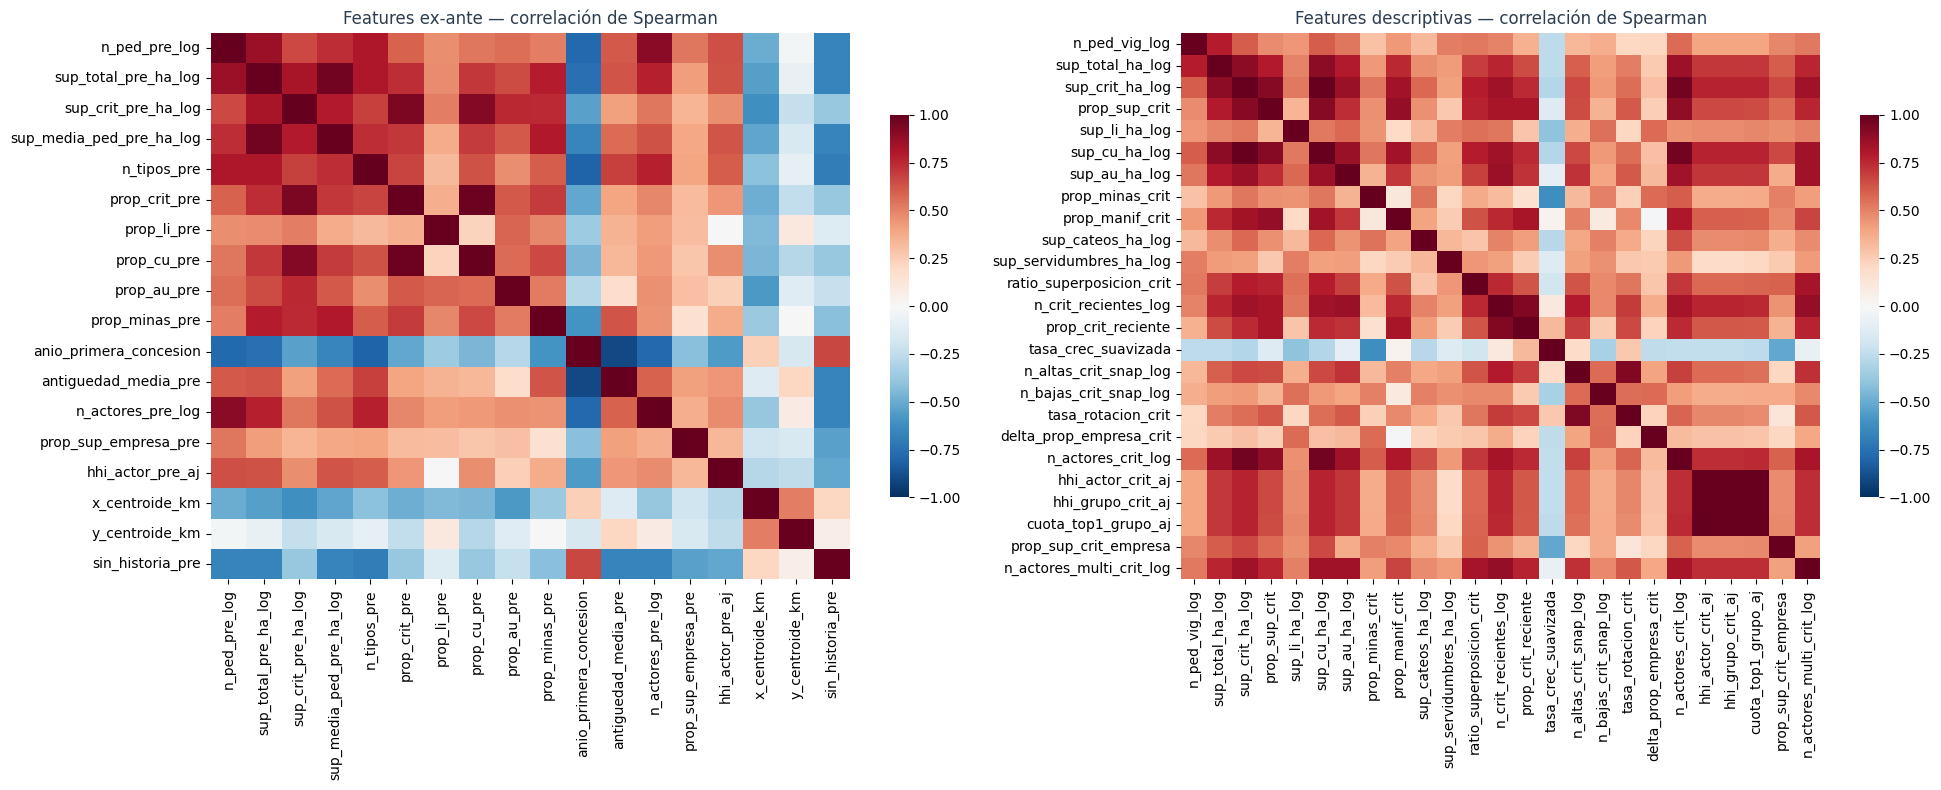

In [30]:
def filtrar_correlacion(df, cols, umbral=0.85, forzar=()):
    constantes = [c for c in cols if df[c].nunique() <= 1]
    cols = [c for c in cols if c not in constantes]
    corr = df[cols].corr(method='spearman').abs()
    media = corr.mean()
    pares = sorted(((corr.loc[x, y], x, y) for x, y in combinations(cols, 2) if corr.loc[x, y] > umbral),
                   reverse=True)
    excluir, registro = set(constantes), []
    for r, x, y in pares:
        if x in excluir or y in excluir:
            continue
        candidatas = [c for c in (x, y) if c not in forzar]
        if not candidatas:
            registro.append({'feature_a': x, 'feature_b': y, 'rho': round(r, 3), 'excluida': '(ambas forzadas)'})
            continue
        quitar = max(candidatas, key=lambda c: media[c])
        excluir.add(quitar)
        registro.append({'feature_a': x, 'feature_b': y, 'rho': round(r, 3), 'excluida': quitar})
    return [c for c in cols if c not in excluir], sorted(excluir), pd.DataFrame(registro)

FEATURES_FORZAR = ['sup_crit_pre_ha_log', 'prop_sup_empresa_pre',
                   'sup_crit_ha_log', 'prop_sup_crit', 'prop_crit_reciente', 'n_altas_crit_snap_log', 'hhi_grupo_crit_aj']
FEATURES_EXANTE_FINALES, EXCLUIDAS_EXANTE, reg_exante = filtrar_correlacion(tabla_mun, FEATURES_EXANTE, forzar=FEATURES_FORZAR)
FEATURES_DESC_FINALES, EXCLUIDAS_DESC, reg_desc = filtrar_correlacion(tabla_mun, FEATURES_DESCRIPTIVAS, forzar=FEATURES_FORZAR)

print(f'Ex-ante: {len(FEATURES_EXANTE)} → {len(FEATURES_EXANTE_FINALES)} | excluidas: {EXCLUIDAS_EXANTE}')
display(reg_exante)
print(f'Descriptivas: {len(FEATURES_DESCRIPTIVAS)} → {len(FEATURES_DESC_FINALES)} | excluidas: {EXCLUIDAS_DESC}')
display(reg_desc)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, cols, titulo in [(axes[0], FEATURES_EXANTE, 'Features ex-ante'),
                         (axes[1], FEATURES_DESCRIPTIVAS, 'Features descriptivas')]:
    sns.heatmap(tabla_mun[cols].corr(method='spearman'), cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax, cbar_kws={'shrink': 0.7})
    ax.set_title(f'{titulo} — correlación de Spearman', color=COLORES['texto'])
plt.tight_layout()
plt.show()

### 8.4 Estrategia de validación

Con 50 municipios y ~13 casos positivos, separar un conjunto de test fijo del 20 % deja 2 o 3 positivos: cualquier métrica sería inestable. Se adopta:

- **Validación cruzada estratificada de 5 folds** con asignación fija (`fold_*`, semilla 42) exportada para que NB04 sea reproducible; LOO-CV como verificación.
- **Validez temporal por diseño:** las features *ex-ante* son anteriores a 2022 y `target_aceleracion` se construye con información de 2022 en adelante, lo que cumple el objetivo de la partición temporal sin sacrificar observaciones.
- **Escalado dentro del pipeline:** `StandardScaler` (KNN, K-Means) se ajusta **dentro de cada fold** (`Pipeline` de scikit-learn) en NB04. Escalar antes de dividir filtraría información del conjunto de validación, por eso aquí se exportan las features sin escalar.

In [31]:
for t in ['target_alta_presion', 'target_aceleracion']:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    folds = pd.Series(-1, index=tabla_mun.index)
    for k, (_, idx_val) in enumerate(skf.split(tabla_mun, tabla_mun[t])):
        folds.iloc[idx_val] = k
    tabla_mun[f'fold_{t}'] = folds.astype(int)
    print(f'{t}: positivos por fold → {tabla_mun.groupby(f"fold_{t}")[t].sum().tolist()}')

target_alta_presion: positivos por fold → [2, 2, 3, 3, 3]
target_aceleracion: positivos por fold → [2, 2, 3, 3, 3]


### 8.5 Preprocesamiento de la tabla de actores

- `log1p` en conteos y superficies; la variación de superficie entre cortes puede ser negativa, por eso usa **log con signo** (`sign(x)·log1p(|x|)`).
- Imputación: `anios_actividad = 0` con bandera `sin_fecha_actor` cuando ningún pedimento tiene fecha.
- Filtro de redundancia sobre los actores aptos, protegiendo las variables que responden directamente al Objetivo B (superficie crítica, dominancia territorial y posición en la red).
- Isolation Forest no depende de distancias, por lo que no requiere escalado.

In [32]:
COLS_LOG_ACTOR = ['n_pedimentos', 'n_ped_crit', 'sup_total_ha', 'sup_crit_ha', 'sup_media_ped_ha', 'sup_crit_grupo_ha',
                  'n_ingresos_cartera', 'n_salidas_cartera', 'fuerza_cotitularidad', 'tam_componente']
for c in COLS_LOG_ACTOR:
    actor[f'{c}_log'] = np.log1p(actor[c])
actor['delta_sup_crit_snap_slog'] = np.sign(actor['delta_sup_crit_snap_ha']) * np.log1p(actor['delta_sup_crit_snap_ha'].abs())

FEATURES_ACTOR = [
    'n_pedimentos_log', 'n_ped_crit_log', 'sup_total_ha_log', 'sup_crit_ha_log', 'sup_media_ped_ha_log',
    'prop_crit', 'municipios_distintos', 'departamentos_distintos', 'hhi_cartera_mun', 'cuota_max_municipal',
    'sup_crit_grupo_ha_log', 'municipios_grupo', 'n_miembros_grupo',
    'prop_minas', 'anios_actividad', 'prop_recientes', 'prop_vigentes',
    'n_ingresos_cartera_log', 'n_salidas_cartera_log', 'delta_sup_crit_snap_slog',
    'prop_cotitularidad', 'grado_cotitularidad', 'fuerza_cotitularidad_log', 'intermediacion', 'tam_componente_log',
]

print('Nulos antes de imputar:')
nulos_actor = actor[FEATURES_ACTOR].isna().sum()
print(nulos_actor[nulos_actor > 0] if nulos_actor.sum() else 'ninguno')

actor['sin_fecha_actor'] = actor['anios_actividad'].isna().astype(int)
actor['anios_actividad'] = actor['anios_actividad'].fillna(0)
actor['hhi_cartera_mun'] = actor['hhi_cartera_mun'].fillna(1)

apto = actor[actor['apto_anomalias'] == 1]
FEATURES_FORZAR_ACTOR = ['sup_crit_ha_log', 'cuota_max_municipal', 'grado_cotitularidad', 'intermediacion']
FEATURES_ACTOR_FINALES, EXCLUIDAS_ACTOR, reg_actor = filtrar_correlacion(apto, FEATURES_ACTOR, forzar=FEATURES_FORZAR_ACTOR)
print(f'\nActores aptos para Isolation Forest: {len(apto)} de {len(actor)}')
print(f'Features actor: {len(FEATURES_ACTOR)} → {len(FEATURES_ACTOR_FINALES)} | excluidas: {EXCLUIDAS_ACTOR}')
display(reg_actor)

Nulos antes de imputar:
anios_actividad    40
dtype: int64

Actores aptos para Isolation Forest: 661 de 689
Features actor: 25 → 15 | excluidas: ['fuerza_cotitularidad_log', 'municipios_distintos', 'municipios_grupo', 'n_ped_crit_log', 'prop_cotitularidad', 'prop_crit', 'prop_vigentes', 'sup_crit_grupo_ha_log', 'sup_total_ha_log', 'tam_componente_log']


,feature_a,feature_b,rho,excluida
0,sup_crit_ha_log,sup_crit_grupo_ha_log,0.998,sup_crit_grupo_ha_log
1,grado_cotitularidad,fuerza_cotitularidad_log,0.994,fuerza_cotitularidad_log
2,municipios_distintos,municipios_grupo,0.994,municipios_grupo
3,municipios_distintos,hhi_cartera_mun,0.991,municipios_distintos
4,grado_cotitularidad,tam_componente_log,0.984,tam_componente_log
5,n_ped_crit_log,sup_crit_ha_log,0.975,n_ped_crit_log
6,sup_crit_ha_log,cuota_max_municipal,0.967,(ambas forzadas)
7,prop_cotitularidad,grado_cotitularidad,0.955,prop_cotitularidad
8,sup_total_ha_log,sup_media_ped_ha_log,0.904,sup_total_ha_log
9,prop_crit,cuota_max_municipal,0.868,prop_crit


---
## Sección 9 — Exportación de artefactos

| Archivo | Contenido | Destino |
|---|---|---|
| `features_territoriales.csv` | 50 municipios × features descriptivas y *ex-ante*, subíndices, IPT, robustez, targets y folds | NB04: clasificación y clustering |
| `features_actores.csv` | Actores × features de cartera, dinámica y red (personas físicas seudonimizadas) | NB04: Isolation Forest |
| `centroides_pedimentos.csv` | Un punto por pedimento (EPSG:5345 y WGS84) con banderas por mineral | NB04: DBSCAN y mapas de calor |
| `red_cotitularidad_nodos.csv` / `red_cotitularidad_aristas.csv` | Red de co-titularidad y grupos económicos | Gephi / NetworkX |
| `validacion_andhes_top_ipt.csv` | Top-15 del IPT con columnas vacías para la validación | ANDHES → Precision@10 |
| `metadata_features.json` | Diccionario de variables, parámetros y decisiones | Trazabilidad metodológica |
| `PRIV_DIR/diccionario_actores_privado.csv` | Correspondencia `id_actor` ➜ nombre | **Uso interno, no subir al repositorio** |

In [33]:
COLS_ID_MUN = ['municipio', 'mineral_dominante', 'grupo_top1_publico', 'hhi_confiable']
COLS_IPT = SUBINDICES + ['ipt', 'rank_ipt', 'prob_top_cuartil', 'rank_p05', 'rank_p95', 'prioridad_robusta']
COLS_TARGET = ['target_alta_presion', 'target_aceleracion', 'fold_target_alta_presion', 'fold_target_aceleracion']

tabla_mun['grupo_top1_publico'] = tabla_mun['grupo_top1'].map(publico)
export_mun = tabla_mun.reset_index()[
    COLS_ID_MUN + list(dict.fromkeys(FEATURES_DESCRIPTIVAS + FEATURES_EXANTE)) + COLS_IPT + COLS_TARGET
]
export_mun.to_csv(PROC_DIR / 'features_territoriales.csv', index=False, encoding='utf-8-sig')

COLS_ID_ACTOR = ['id_actor', 'nombre_publico', 'tipo_actor', 'grupo_economico_publico', 'es_juridica',
                 'apto_anomalias', 'es_nuevo_snap', 'sin_fecha_actor', 'id_componente', 'municipio_dominado']
actor['grupo_economico_publico'] = actor['grupo_economico'].map(publico)
export_actor = actor.reset_index(drop=True)[COLS_ID_ACTOR + FEATURES_ACTOR]
export_actor.to_csv(PROC_DIR / 'features_actores.csv', index=False, encoding='utf-8-sig')

privado = actor.reset_index()[['id_actor', 'actor', 'tipo_actor', 'grupo_economico']]
privado.to_csv(PRIV_DIR / 'diccionario_actores_privado.csv', index=False, encoding='utf-8-sig')

pts = base[base['municipio'].notna()].copy()
cent_m = pts.to_crs(CRS_METRICO).geometry.centroid
cent_w = gpd.GeoSeries(cent_m, crs=CRS_METRICO).to_crs(4326)
ids_reg = act_all[SNAP_BASE].groupby('id_registro')['actor'].agg(lambda s: ';'.join(sorted(ID_ACTOR[x] for x in set(s))))
centroides = pd.DataFrame({
    'id_registro': pts['id_registro'], 'expediente': pts['expediente'],
    'municipio': pts['municipio'], 'departamento': pts['departamen'],
    'tipo': pts['tipo'], 'estado': pts['estado'], 'vigente': pts['vigente'].astype(int),
    'anio_inic': pts['anio_inic'], 'area_ha': pts['area_ha'],
    'minerales_criticos': pts['minerales_criticos'].astype(int),
    'min_li': pts['min_li'].astype(int), 'min_cu': pts['min_cu'].astype(int), 'min_au': pts['min_au'].astype(int),
    'tipo_actor': pts['tipo_actor'], 'ids_actores': pts['id_registro'].map(ids_reg),
    'x_5345': cent_m.x.round(2), 'y_5345': cent_m.y.round(2),
    'lon': cent_w.x.round(6), 'lat': cent_w.y.round(6),
})
centroides.to_csv(PROC_DIR / 'centroides_pedimentos.csv', index=False, encoding='utf-8-sig')

nodos = pd.DataFrame({
    'Id': [ID_ACTOR[n] for n in G.nodes],
    'Label': [publico(n) for n in G.nodes],
    'tipo_actor': [tipo_por_actor[n] for n in G.nodes],
    'grupo_economico': [publico(GRUPOS_ECONOMICOS.get(n, n)) for n in G.nodes],
    'presente_snap_base': [int(n in actor.index) for n in G.nodes],
    'grado': [G.degree(n) for n in G.nodes],
    'intermediacion': [round(intermediacion[n], 6) for n in G.nodes],
    'componente': [comp_id[n] for n in G.nodes],
})
nodos = nodos[nodos['grado'] > 0]
aristas = pd.DataFrame([{'Source': ID_ACTOR[u], 'Target': ID_ACTOR[v], 'Weight': d['weight'],
                         'Type': 'Undirected', 'tipo_vinculo': d['tipo']} for u, v, d in G.edges(data=True)])
nodos.to_csv(PROC_DIR / 'red_cotitularidad_nodos.csv', index=False, encoding='utf-8-sig')
aristas.to_csv(PROC_DIR / 'red_cotitularidad_aristas.csv', index=False, encoding='utf-8-sig')

validacion = tabla_mun.nlargest(15, 'ipt').reset_index()[
    ['rank_ipt', 'municipio', 'ipt', 'ipt_magnitud', 'ipt_dinamica', 'ipt_concentracion',
     'prob_top_cuartil', 'prioridad_robusta', 'mineral_dominante', 'grupo_top1_publico']
].round(3)
validacion['conocido_por_andhes'] = ''
validacion['prioridad_andhes'] = ''
validacion['comentarios'] = ''
validacion.to_csv(PROC_DIR / 'validacion_andhes_top_ipt.csv', index=False, encoding='utf-8-sig')

print('Artefactos exportados:')
for f, df in [('features_territoriales.csv', export_mun), ('features_actores.csv', export_actor),
              ('centroides_pedimentos.csv', centroides), ('red_cotitularidad_nodos.csv', nodos),
              ('red_cotitularidad_aristas.csv', aristas), ('validacion_andhes_top_ipt.csv', validacion)]:
    print(f'  ✓ {f:<32} {df.shape[0]:>5} filas × {df.shape[1]:>3} columnas')
print(f'  ✓ diccionario_actores_privado.csv (en {PRIV_DIR}, fuera del repositorio)')

Artefactos exportados:
  ✓ features_territoriales.csv          50 filas ×  60 columnas
  ✓ features_actores.csv               689 filas ×  35 columnas
  ✓ centroides_pedimentos.csv         3339 filas ×  19 columnas
  ✓ red_cotitularidad_nodos.csv        189 filas ×   8 columnas
  ✓ red_cotitularidad_aristas.csv      214 filas ×   5 columnas
  ✓ validacion_andhes_top_ipt.csv       15 filas ×  13 columnas
  ✓ diccionario_actores_privado.csv (en /content/privado, fuera del repositorio)


### Diccionario de variables y metadata

In [34]:
DICCIONARIO = {
    'municipio': 'Municipio (unidad de análisis territorial)',
    'mineral_dominante': 'Mineral crítico con mayor superficie vigente en el municipio (Li, Cu, Au o Ninguno)',
    'grupo_top1_publico': 'Grupo económico con mayor participación en la superficie crítica (personas físicas seudonimizadas)',
    'hhi_confiable': f'True si el municipio tiene al menos {MIN_PED_HHI} pedimentos críticos vigentes',
    'n_ped_vig_log': 'log1p de pedimentos vigentes con mineral informado',
    'sup_total_ha_log': 'log1p de superficie vigente total (ha)',
    'sup_crit_ha_log': 'log1p de superficie vigente con Li, Cu o Au (ha)',
    'prop_sup_crit': 'Superficie crítica / superficie total vigente',
    'sup_li_ha_log': 'log1p de superficie vigente que declara Li (ha)',
    'sup_cu_ha_log': 'log1p de superficie vigente que declara Cu (ha)',
    'sup_au_ha_log': 'log1p de superficie vigente que declara Au (ha)',
    'prop_minas_crit': 'Proporción de pedimentos críticos en etapa Mina (explotación)',
    'prop_manif_crit': 'Proporción de pedimentos críticos en etapa Manifestación (descubrimiento)',
    'sup_cateos_ha_log': 'log1p de superficie vigente en cateos (exploración, sin mineral informado)',
    'sup_servidumbres_ha_log': 'log1p de superficie vigente en servidumbres (infraestructura)',
    'ratio_superposicion_crit': '1 − área de la unión / suma de áreas de pedimentos críticos (EPSG:5345)',
    'n_crit_recientes_log': f'log1p de pedimentos críticos vigentes iniciados desde {CORTE_RECIENTE}',
    'prop_crit_reciente': f'Pedimentos críticos iniciados desde {CORTE_RECIENTE} / pedimentos críticos con fecha',
    'tasa_crec_suavizada': 'log((recientes + 1) / (previas + 1)) de pedimentos críticos',
    'n_altas_crit_snap_log': 'log1p de expedientes críticos nuevos entre cortes (marzo→junio→agosto)',
    'n_bajas_crit_snap_log': 'log1p de expedientes críticos que salen entre cortes',
    'tasa_rotacion_crit': '(altas + bajas críticas entre cortes) / expedientes críticos en marzo',
    'delta_prop_empresa_crit': 'Cambio marzo→agosto en la proporción de superficie crítica en manos de empresas',
    'n_actores_crit_log': 'log1p de actores individuales con superficie crítica vigente',
    'hhi_actor_crit_aj': 'HHI de superficie crítica por actor individual (0 si hhi_confiable es False)',
    'hhi_grupo_crit_aj': 'HHI de superficie crítica por grupo económico (0 si hhi_confiable es False)',
    'cuota_top1_grupo_aj': 'Participación del grupo principal en la superficie crítica (0 si hhi_confiable es False)',
    'prop_sup_crit_empresa': 'Proporción de superficie crítica vigente en manos de empresas',
    'n_actores_multi_crit_log': 'log1p de actores con más de un pedimento crítico en el municipio',
    'n_ped_pre_log': f'log1p de pedimentos iniciados antes de {CORTE_RECIENTE}',
    'sup_total_pre_ha_log': f'log1p de superficie de pedimentos iniciados antes de {CORTE_RECIENTE} (ha)',
    'sup_crit_pre_ha_log': f'log1p de superficie crítica iniciada antes de {CORTE_RECIENTE} (ha)',
    'sup_media_ped_pre_ha_log': f'log1p de superficie media por pedimento previo a {CORTE_RECIENTE}',
    'n_tipos_pre': f'Tipos de concesión distintos antes de {CORTE_RECIENTE}',
    'prop_crit_pre': f'Proporción de superficie crítica antes de {CORTE_RECIENTE}',
    'prop_li_pre': f'Proporción de superficie con Li antes de {CORTE_RECIENTE}',
    'prop_cu_pre': f'Proporción de superficie con Cu antes de {CORTE_RECIENTE}',
    'prop_au_pre': f'Proporción de superficie con Au antes de {CORTE_RECIENTE}',
    'prop_minas_pre': f'Proporción de pedimentos en etapa Mina antes de {CORTE_RECIENTE}',
    'anio_primera_concesion': f'Año de la primera concesión con fecha ({CORTE_RECIENTE} si no hay historia previa)',
    'antiguedad_media_pre': f'{CORTE_RECIENTE} − año medio de inicio de los pedimentos previos',
    'n_actores_pre_log': f'log1p de actores con pedimentos previos a {CORTE_RECIENTE}',
    'prop_sup_empresa_pre': f'Proporción de superficie en manos de empresas antes de {CORTE_RECIENTE}',
    'hhi_actor_pre_aj': f'HHI de superficie por actor antes de {CORTE_RECIENTE} (0 con menos de {MIN_PED_HHI} pedimentos)',
    'x_centroide_km': 'Coordenada X media de los centroides de pedimentos (EPSG:5345, km)',
    'y_centroide_km': 'Coordenada Y media de los centroides de pedimentos (EPSG:5345, km)',
    'sin_historia_pre': f'1 si el municipio no tiene pedimentos con fecha anterior a {CORTE_RECIENTE}',
    'ipt_magnitud': 'Subíndice de magnitud (0–1)',
    'ipt_dinamica': 'Subíndice de dinámica (0–1)',
    'ipt_concentracion': 'Subíndice de concentración (0–1)',
    'ipt': 'Índice de Presión Territorial: promedio de los tres subíndices',
    'rank_ipt': 'Posición en el ranking IPT (1 = mayor presión)',
    'prob_top_cuartil': f'Proporción de {N_SIM} ponderaciones aleatorias en que el municipio queda en el cuartil superior',
    'rank_p05': 'Percentil 5 de la posición en el ranking bajo ponderaciones aleatorias',
    'rank_p95': 'Percentil 95 de la posición en el ranking bajo ponderaciones aleatorias',
    'prioridad_robusta': 'True si prob_top_cuartil ≥ 0,8',
    'target_alta_presion': 'Target: 1 si IPT ≥ percentil 75',
    'target_aceleracion': 'Target: 1 si subíndice de dinámica ≥ percentil 75',
    'fold_target_alta_presion': 'Fold (0–4) de validación cruzada estratificada para target_alta_presion',
    'fold_target_aceleracion': 'Fold (0–4) de validación cruzada estratificada para target_aceleracion',
}

DICCIONARIO_ACTOR = {
    'id_actor': 'Identificador estable del actor individual normalizado',
    'nombre_publico': 'Nombre del actor; personas físicas seudonimizadas (Ley 25.326)',
    'tipo_actor': 'empresa, persona_fisica, gubernamental, cooperativa, comunidad',
    'grupo_economico_publico': 'Grupo económico documentado (o el propio actor)',
    'es_juridica': '1 si tipo_actor es empresa',
    'apto_anomalias': '1 si el actor entra al Isolation Forest (excluye gubernamentales)',
    'es_nuevo_snap': '1 si el actor no figuraba en el corte de marzo 2026',
    'sin_fecha_actor': '1 si ningún pedimento del actor tiene fecha_inic',
    'id_componente': 'Componente conexo de la red de co-titularidad (-1 si el actor está aislado)',
    'municipio_dominado': 'Municipio donde el actor tiene su mayor participación de superficie crítica',
    'n_pedimentos_log': 'log1p de pedimentos del actor',
    'n_ped_crit_log': 'log1p de pedimentos críticos del actor',
    'sup_total_ha_log': 'log1p de superficie del actor (ha, co-titularidad repartida)',
    'sup_crit_ha_log': 'log1p de superficie crítica del actor (ha, co-titularidad repartida)',
    'sup_media_ped_ha_log': 'log1p de superficie media por pedimento del actor',
    'prop_crit': 'Proporción de pedimentos críticos en la cartera',
    'sup_crit_grupo_ha_log': 'log1p de superficie crítica del grupo económico al que pertenece el actor (ha)',
    'municipios_grupo': 'Municipios distintos en la cartera del grupo económico',
    'n_miembros_grupo': 'Sociedades del catastro que integran el grupo económico (1 si no hay vínculo documentado)',
    'municipios_distintos': 'Municipios distintos en la cartera',
    'departamentos_distintos': 'Departamentos distintos en la cartera',
    'hhi_cartera_mun': 'HHI de la cartera del actor entre municipios (1 = todo en un municipio)',
    'cuota_max_municipal': 'Mayor participación del actor en la superficie crítica vigente de un municipio',
    'prop_minas': 'Proporción de la cartera en etapa Mina',
    'anios_actividad': 'Año del pedimento más reciente − año del más antiguo',
    'prop_recientes': f'Proporción de pedimentos iniciados desde {CORTE_RECIENTE}',
    'prop_vigentes': 'Proporción de pedimentos vigentes',
    'n_ingresos_cartera_log': 'log1p de expedientes que ingresan a la cartera entre marzo y agosto',
    'n_salidas_cartera_log': 'log1p de expedientes que salen de la cartera entre marzo y agosto',
    'delta_sup_crit_snap_slog': 'Variación de superficie crítica marzo→agosto con log con signo',
    'prop_cotitularidad': 'Proporción de pedimentos compartidos con otros titulares',
    'grado_cotitularidad': 'Socios distintos en la red de co-titularidad',
    'fuerza_cotitularidad_log': 'log1p de expedientes compartidos con socios',
    'intermediacion': 'Centralidad de intermediación normalizada en la red',
    'tam_componente_log': 'log1p del tamaño del componente conexo del actor en la red',
}

faltan = ([c for c in export_mun.columns if c not in DICCIONARIO]
          + [c for c in export_actor.columns if c not in DICCIONARIO_ACTOR])
print(f'Columnas exportadas sin descripción: {faltan if faltan else "ninguna"}')

metadata = {
    'version': '2.0',
    'fecha_generacion': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'snapshot_base': SNAP_BASE,
    'snapshots_comparacion': MESES,
    'unidad_analisis': 'municipio',
    'n_municipios': int(len(export_mun)),
    'n_actores': int(len(export_actor)),
    'parametros': {'CRS_METRICO': f'EPSG:{CRS_METRICO}', 'CORTE_RECIENTE': CORTE_RECIENTE,
                   'MIN_PED_HHI': MIN_PED_HHI, 'N_SIM': N_SIM, 'SEED': SEED},
    'minerales_criticos': {'codigos': MINERALES_CRITICOS,
                           'criterio': 'Clasificación propia del proyecto (Li, Cu, Au; Ag excluida). No equivale a listas USGS/UE/SEGEMAR.'},
    'normalizacion_titulares': {'crosswalk': 'data/modified/titulares_crosswalk.csv',
                                'clasificacion': 'data/modified/clasificacion_actores.csv',
                                'fusiones_adicionales': FUSIONES_ADICIONALES,
                                'vacancia': 'VACANCIA SOLICITADA reclasificada como vacancia y excluida de actores'},
    'grupos_economicos': GRUPOS_ECONOMICOS,
    'cotitularidad': 'Registros con varios titulares desagregados; superficie repartida en partes iguales',
    'ipt': {'dimensiones': DIMENSIONES, 'normalizacion': 'rango percentil entre municipios con valor positivo; ceros = 0',
            'agregacion': 'promedio de componentes por dimensión y promedio simple de dimensiones',
            'spearman_vs_minmax': round(float(rho_norm), 3),
            'coincidencias_top10_sin_dimension': coincidencias,
            'n_prioridad_robusta': int(tabla_mun['prioridad_robusta'].sum()),
            'pendiente': 'Validar top-10 con referentes de ANDHES (validacion_andhes_top_ipt.csv)'},
    'targets': {
        'target_alta_presion': {'criterio': f'IPT >= percentil 75 ({UMBRAL_IPT:.4f})',
                                'clase_1': int(tabla_mun['target_alta_presion'].sum())},
        'target_aceleracion': {'criterio': f'ipt_dinamica >= percentil 75 ({UMBRAL_DIN:.4f})',
                               'clase_1': int(tabla_mun['target_aceleracion'].sum()),
                               'recomendado_para': 'modelo supervisado predictivo con features ex-ante'},
    },
    'features_descriptivas': FEATURES_DESCRIPTIVAS,
    'features_descriptivas_finales': FEATURES_DESC_FINALES,
    'features_exante': FEATURES_EXANTE,
    'features_exante_finales': FEATURES_EXANTE_FINALES,
    'features_actor': FEATURES_ACTOR,
    'features_actor_finales': FEATURES_ACTOR_FINALES,
    'excluidas_alta_correlacion': {'exante': EXCLUIDAS_EXANTE, 'descriptivas': EXCLUIDAS_DESC, 'actor': EXCLUIDAS_ACTOR},
    'tratamiento_nulos': {
        'fecha_inic': 'Registros sin fecha excluidos de features históricas; sin imputación',
        'municipio': 'Registros sin municipio excluidos de la tabla territorial',
        'hhi': f'HHI no interpretable con menos de {MIN_PED_HHI} pedimentos críticos: versión _aj = 0',
        'sin_historia_pre': 'Conteos y superficies = 0; anio_primera_concesion = CORTE_RECIENTE',
        'actores': 'anios_actividad = 0 y bandera sin_fecha_actor si no hay fechas',
    },
    'validacion': 'StratifiedKFold(5, shuffle=True, random_state=42) exportado en fold_*; LOO-CV como verificación; escalado dentro del Pipeline en NB04',
    'privacidad': 'Personas físicas seudonimizadas en artefactos públicos; diccionario privado fuera del repositorio',
    'limitaciones': [
        '50 unidades territoriales: alta varianza de las métricas',
        'Sesgo de supervivencia: fecha_inic solo existe para pedimentos que siguen en el catastro',
        'Solo minería formal registrada',
        'Clasificación de tipo_actor heurística para titulares nuevos no revisados',
        'Grupos económicos limitados a vínculos documentados',
    ],
    'diccionario_variables': {'features_territoriales': DICCIONARIO, 'features_actores': DICCIONARIO_ACTOR},
}

with open(PROC_DIR / 'metadata_features.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)
print('✓ metadata_features.json guardado')

Columnas exportadas sin descripción: ninguna
✓ metadata_features.json guardado


### Guardar los artefactos en GitHub

Los archivos quedan en la copia del repositorio dentro de Colab, que se borra al cerrar la sesión (y la celda de clonación hace `reset --hard` al re-ejecutarse). Para conservarlos, descargalos desde el panel de archivos o con `files.download(...)` y subilos a `data/modified/`. **No subas** `diccionario_actores_privado.csv`: está en `PRIV_DIR` justamente para que quede fuera del repositorio.

---
## Resumen del notebook

**Qué se construyó**

- Tabla de **50 municipios** con features descriptivas (magnitud por mineral, etapa, superposición, dinámica entre cortes, corporativización, concentración a dos niveles) y *ex-ante* (estructura previa a 2022).
- **IPT en tres dimensiones** con análisis de robustez (pesos aleatorios, normalización alternativa, dimensión excluida) y bandera de **prioridad robusta**.
- Dos targets: `target_alta_presion` (priorización) y `target_aceleracion` (alerta temprana, recomendado para el modelo supervisado).
- Tabla de **actores individuales** con features de cartera, dominancia territorial, dinámica y **red de co-titularidad**.
- Insumos para DBSCAN (centroides) y Gephi (nodos y aristas), plantilla de validación para ANDHES y metadata con diccionario completo.

**Próximos pasos (NB04)**

1. Enviar `validacion_andhes_top_ipt.csv` a ANDHES y calcular Precision@10 **antes** de modelar.
2. Clustering: K-Means (baseline) y DBSCAN sobre `centroides_pedimentos.csv`; agregar al municipio la proporción de pedimentos en clusters de alta densidad como feature adicional.
3. Clasificación supervisada: Decision Tree ➜ Random Forest ➜ KNN con `Pipeline` + `GridSearchCV` (F1 ponderado) sobre `FEATURES_EXANTE_FINALES` y `target_aceleracion`, usando los folds exportados.
4. Isolation Forest sobre `features_actores.csv` filtrando `apto_anomalias == 1` y `FEATURES_ACTOR_FINALES`; revisar el top-N con ANDHES como patrones a investigar, no como acusaciones.

**Pendientes metodológicos**

- Ampliar `GRUPOS_ECONOMICOS` con la investigación documental de perfiles corporativos (incluido el caso TOLAR GRANDE LITHIUM S.A.).
- Validar con ANDHES la hipótesis de incluir `prop_sup_crit_empresa` en la dimensión de concentración y, si corresponde, la ponderación de dimensiones.
- Revisar la clasificación de `tipo_actor` de titulares que aparezcan en cortes futuros y no estén en `clasificacion_actores.csv`.